# EDA to MLflow Pipeline

In [1]:
import pandas as pd
import sqlite3
import os

from rich.logging import RichHandler
import logging

In [2]:
# Configure logging with Rich
logging.basicConfig(
    level="INFO",
    format="%(message)s",
    datefmt="[%X]",
    handlers=[RichHandler(rich_tracebacks=True)]
)

logger = logging.getLogger("rich")

In [3]:
# 1) Load raw CSV Files
# 1) Load raw CSV Files
data_dir = os.path.join("data", "Corrected-Data")

patients_path = os.path.join(data_dir, "patients.csv")
visits_path = os.path.join(data_dir, "visits.csv")
billing_path = os.path.join(data_dir, "billing.csv")

for path in (patients_path, visits_path, billing_path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing data file: {path}")

patients = pd.read_csv(patients_path)
visits = pd.read_csv(visits_path)
billing = pd.read_csv(billing_path)

logger.info("patients shape: %s", patients.shape)
logger.info("visits shape: %s", visits.shape)
logger.info("billing shape: %s", billing.shape)




[18:19:21] INFO     patients shape: (5000, 7)                                                      ]8;id=4438370;file:///tmp/ipykernel_3060/1631273376.py\1631273376.py]8;;\:]8;id=4438371;file:///tmp/ipykernel_3060/1631273376.py#17\17]8;;\

           INFO     visits shape: (25000, 8)                                                       ]8;id=4438377;file:///tmp/ipykernel_3060/1631273376.py\1631273376.py]8;;\:]8;id=4438378;file:///tmp/ipykernel_3060/1631273376.py#18\18]8;;\

           INFO     billing shape: (25000, 7)                                                      ]8;id=4438384;file:///tmp/ipykernel_3060/1631273376.py\1631273376.py]8;;\:]8;id=4438385;file:///tmp/ipykernel_3060/1631273376.py#19\19]8;;\

In [4]:

# Create db folder, if it doesn't exits
os.makedirs("./db", exist_ok=True)

# Connect to sqlite and then create db
conn = sqlite3.connect("./db/hospital.db")
cursor = conn.cursor()
logger.info("Database connected: %s", conn)

           INFO     Database connected: <sqlite3.Connection object at 0x7b50c423a3e0>               ]8;id=4438392;file:///tmp/ipykernel_3060/2370726886.py\2370726886.py]8;;\:]8;id=4438393;file:///tmp/ipykernel_3060/2370726886.py#7\7]8;;\

In [5]:

# write all three dataframes into sqlite tables
patients.to_sql("patients", conn, if_exists="replace", index=False)
visits.to_sql("visits", conn, if_exists="replace", index=False)
billing.to_sql("billing", conn, if_exists="replace", index=False)

logger.info("All three tables loaded into hospital db")

           INFO     All three tables loaded into hospital db                                        ]8;id=4438400;file:///tmp/ipykernel_3060/3435725956.py\3435725956.py]8;;\:]8;id=4438401;file:///tmp/ipykernel_3060/3435725956.py#6\6]8;;\

In [6]:
# 4) Quick preview of tables
logger.info("=== PATIENTS (first 3 rows) ===")
logger.info(pd.read_sql("select * from patients limit 3", conn).to_string())

logger.info("=== VISITS (first 3 rows) ===")
logger.info(pd.read_sql("select * from visits limit 3", conn).to_string())

logger.info("=== BILLING (first 3 rows) ===")
logger.info(pd.read_sql("select * from billing limit 3", conn).to_string())

           INFO     === PATIENTS (first 3 rows) ===                                                 ]8;id=4438408;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438409;file:///tmp/ipykernel_3060/4173315521.py#2\2]8;;\

           INFO        patient_id  age gender       city insurance_provider  chronic_flag           ]8;id=4438415;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438416;file:///tmp/ipykernel_3060/4173315521.py#3\3]8;;\
                    registration_date                                                                              
                    0           1   52      M  Bangalore            CareOne             1                          
                    5/6/2025                                                                                       
                    1           2   15      F     Mumbai            CareOne             0                          
                    12/27/2025                                                                                     
                    2           3   72      F  Bangalore         SecureLife             1                          
                    1/28/2025                                                                                      

           INFO     === VISITS (first 3 rows) ===                                                   ]8;id=4438422;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438423;file:///tmp/ipykernel_3060/4173315521.py#5\5]8;;\

           INFO        visit_id  patient_id  visit_date  department visit_type                      ]8;id=4438429;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438430;file:///tmp/ipykernel_3060/4173315521.py#6\6]8;;\
                    length_of_stay_hours risk_score  doctor_id                                                     
                    0         1           1  10/16/2025  Cardiology        OPD                                     
                    23.15        Low        186                                                                    
                    1         2           1   12/9/2025         ICU        ICU                                     
                    39.98       High        149                                                                    
                    2         3           1  10/29/2025          ER         ER                                     
                    20.97     Medium        122                                                                    

           INFO     === BILLING (first 3 rows) ===                                                  ]8;id=4438436;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438437;file:///tmp/ipykernel_3060/4173315521.py#8\8]8;;\

           INFO        bill_id  visit_id  billed_amount  approved_amount claim_status  payment_days ]8;id=4438443;file:///tmp/ipykernel_3060/4173315521.py\4173315521.py]8;;\:]8;id=4438444;file:///tmp/ipykernel_3060/4173315521.py#9\9]8;;\
                    billing_date                                                                                   
                    0        1         1       23550.00         21429.62         Paid           8.0                
                    2025-11-03                                                                                     
                    1        2         2       88539.01         19725.49      Pending           NaN                
                    2025-12-16                                                                                     
                    2        3         3       25949.30          1580.95     Rejected           NaN                
                    2025-11-20                                                                                     

## Operational Analytics

In [7]:
dept_workload = pd.read_sql("""
SELECT 
    department,
    COUNT(visit_id)                             AS total_visits,
    ROUND(AVG(length_of_stay_hours), 2)         AS avg_los_hours,
    ROUND(MAX(length_of_stay_hours), 2)         AS max_los_hours,
    SUM(CASE WHEN risk_score = 'High'
        THEN 1 ELSE 0 END)                      AS high_risk_visits
    FROM visits
    GROUP BY department
    ORDER BY total_visits DESC
""", conn)

logger.info(dept_workload.to_string(index=False))

# Which doctors handle the most high-risk patients?
doctor_risk = pd.read_sql("""
    SELECT 
        doctor_id,
        COUNT(visit_id)                              AS total_visits,
        SUM(CASE WHEN risk_score = 'High' 
            THEN 1 ELSE 0 END)                       AS high_risk_cases,
        ROUND(
            100.0 * SUM(CASE WHEN risk_score = 'High' 
            THEN 1 ELSE 0 END) / COUNT(visit_id), 1) AS high_risk_pct
    FROM visits
    GROUP BY doctor_id
    ORDER BY high_risk_cases DESC
    LIMIT 10
""", conn)

logger.info("Top 10 Doctors by High Risk Cases")
logger.info(doctor_risk.to_string(index=False))

# How many visits does each patient make on average?
visit_patterns = pd.read_sql("""
    SELECT 
        visit_frequency_bucket,
        COUNT(patient_id) AS num_patients
    FROM (
        SELECT 
            patient_id,
            COUNT(visit_id) AS visit_count,
            CASE 
                WHEN COUNT(visit_id) = 1     THEN '1 visit'
                WHEN COUNT(visit_id) BETWEEN 2 AND 3 THEN '2-3 visits'
                WHEN COUNT(visit_id) BETWEEN 4 AND 5 THEN '4-5 visits'
                ELSE '6+ visits'
            END AS visit_frequency_bucket
        FROM visits
        GROUP BY patient_id
    )
    GROUP BY visit_frequency_bucket
    ORDER BY num_patients DESC
""", conn)

logger.info("Patient Visit Frequency Distribution")
logger.info(visit_patterns.to_string(index=False))

# 8) Risk Score Distribution by Department
risk_by_dept = pd.read_sql("""
    SELECT 
        department,
        SUM(CASE WHEN risk_score = 'Low'    THEN 1 ELSE 0 END) AS low,
        SUM(CASE WHEN risk_score = 'Medium' THEN 1 ELSE 0 END) AS medium,
        SUM(CASE WHEN risk_score = 'High'   THEN 1 ELSE 0 END) AS high,
        COUNT(*) AS total
    FROM visits
    GROUP BY department
    ORDER BY high DESC
""", conn)

print("Risk Score Distribution by Department")
print(risk_by_dept.to_string(index=False))

           INFO      department  total_visits  avg_los_hours  max_los_hours  high_risk_visits      ]8;id=4438451;file:///tmp/ipykernel_3060/1419670600.py\1419670600.py]8;;\:]8;id=4438452;file:///tmp/ipykernel_3060/1419670600.py#14\14]8;;\
                        General          5757          14.01          36.54                24                      
                    Orthopedics          4474          23.02          52.99                54                      
                     Cardiology          4071          32.59          70.74               489                      
                             ER          3896          11.95          30.78               139                      
                            ICU          3415          56.86          78.42              2975                      
                      Neurology          3387          27.69          66.16               635                      

           INFO     Top 10 Doctors by High Risk Cases                                              ]8;id=4438458;file:///tmp/ipykernel_3060/1419670600.py\1419670600.py]8;;\:]8;id=4438459;file:///tmp/ipykernel_3060/1419670600.py#32\32]8;;\

           INFO      doctor_id  total_visits  high_risk_cases  high_risk_pct                       ]8;id=4438465;file:///tmp/ipykernel_3060/1419670600.py\1419670600.py]8;;\:]8;id=4438466;file:///tmp/ipykernel_3060/1419670600.py#33\33]8;;\
                           114           260               61           23.5                                       
                           130           264               60           22.7                                       
                           187           262               57           21.8                                       
                           126           244               55           22.5                                       
                           102           271               55           20.3                                       
                           189           240               54           22.5                                       
                           158           252               53           21.0                                       
                           171           260               52           20.0                                       
                           150           252               52           20.6                                       
                           194           267               51           19.1                                       

           INFO     Patient Visit Frequency Distribution                                           ]8;id=4438472;file:///tmp/ipykernel_3060/1419670600.py\1419670600.py]8;;\:]8;id=4438473;file:///tmp/ipykernel_3060/1419670600.py#57\57]8;;\

           INFO     visit_frequency_bucket  num_patients                                           ]8;id=4438479;file:///tmp/ipykernel_3060/1419670600.py\1419670600.py]8;;\:]8;id=4438480;file:///tmp/ipykernel_3060/1419670600.py#58\58]8;;\
                                 6+ visits          1816                                                           
                                4-5 visits          1776                                                           
                                2-3 visits          1267                                                           
                                   1 visit           141                                                           

Risk Score Distribution by Department
 department  low  medium  high  total
        ICU   10     430  2975   3415
  Neurology  875    1877   635   3387
 Cardiology 1063    2519   489   4071
         ER 1771    1986   139   3896
Orthopedics 3426     994    54   4474
    General 4590    1143    24   5757


Financial Analytics

In [8]:
# Revenue and claim outcomes by insurance provider.
insurance_billing = pd.read_sql("""
    SELECT 
        p.insurance_provider,
        COUNT(b.bill_id)                         AS total_claims,
        ROUND(SUM(b.billed_amount), 0)           AS total_billed,
        ROUND(AVG(b.billed_amount), 0)           AS avg_billed,
        ROUND(SUM(b.approved_amount), 0)         AS total_approved,
        SUM(CASE WHEN b.claim_status = 'Paid'     
            THEN 1 ELSE 0 END)                   AS paid,
        SUM(CASE WHEN b.claim_status = 'Pending'  
            THEN 1 ELSE 0 END)                   AS pending,
        SUM(CASE WHEN b.claim_status = 'Rejected' 
            THEN 1 ELSE 0 END)                   AS rejected
    FROM billing b
    JOIN visits  v ON b.visit_id   = v.visit_id
    JOIN patients p ON v.patient_id = p.patient_id
    GROUP BY p.insurance_provider
    ORDER BY total_billed DESC
""", conn)

logger.info("Insurance Billing Breakdown")
logger.info(insurance_billing.to_string(index=False))

rejection_analysis = pd.read_sql("""
    SELECT 
        p.insurance_provider,
        COUNT(b.bill_id)                              AS total_claims,
        SUM(CASE WHEN b.claim_status = 'Rejected' 
            THEN 1 ELSE 0 END)                        AS rejected_claims,
        ROUND(
            100.0 * SUM(CASE WHEN b.claim_status = 'Rejected' 
            THEN 1 ELSE 0 END) / COUNT(b.bill_id), 1) AS rejection_rate_pct
    FROM billing b
    JOIN visits   v ON b.visit_id   = v.visit_id
    JOIN patients p ON v.patient_id = p.patient_id
    GROUP BY p.insurance_provider
    ORDER BY rejection_rate_pct DESC
""", conn)

logger.info("Claim Rejection Rate by Insurance Provider")
logger.info(rejection_analysis.to_string(index=False))

# How much of what we bill actually gets approved?
revenue_realization = pd.read_sql("""
    SELECT 
        p.insurance_provider,
        ROUND(SUM(b.billed_amount), 0)                AS total_billed,
        ROUND(SUM(b.approved_amount), 0)              AS total_approved,
        ROUND(
            100.0 * SUM(b.approved_amount) / 
            SUM(b.billed_amount), 1)                  AS realization_rate_pct
    FROM billing b
    JOIN visits   v ON b.visit_id   = v.visit_id
    JOIN patients p ON v.patient_id = p.patient_id
    WHERE b.approved_amount IS NOT NULL
    GROUP BY p.insurance_provider
    ORDER BY realization_rate_pct DESC
""", conn)

logger.info("Revenue Realization Rate by Insurance Provider")
logger.info(revenue_realization.to_string(index=False))



           INFO     Insurance Billing Breakdown                                                    ]8;id=4438487;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438488;file:///tmp/ipykernel_3060/2203644646.py#22\22]8;;\

           INFO     insurance_provider  total_claims  total_billed  avg_billed  total_approved     ]8;id=4438494;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438495;file:///tmp/ipykernel_3060/2203644646.py#23\23]8;;\
                    paid  pending  rejected                                                                        
                            HealthPlus          6499   251723095.0     38733.0     124033289.0                     
                    3727     1557      1215                                                                        
                               CareOne          6326   246192121.0     38918.0     107084590.0                     
                    3160     1541      1625                                                                        
                            SecureLife          6197   242381528.0     39113.0     128230940.0                     
                    3723     1498       976                                                                        
                             MediCareX          5978   229000682.0     38307.0     100849491.0                     
                    3028     1500      1450                                                                        

           INFO     Claim Rejection Rate by Insurance Provider                                     ]8;id=4438501;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438502;file:///tmp/ipykernel_3060/2203644646.py#41\41]8;;\

           INFO     insurance_provider  total_claims  rejected_claims  rejection_rate_pct          ]8;id=4438508;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438509;file:///tmp/ipykernel_3060/2203644646.py#42\42]8;;\
                               CareOne          6326             1625                25.7                          
                             MediCareX          5978             1450                24.3                          
                            HealthPlus          6499             1215                18.7                          
                            SecureLife          6197              976                15.7                          

           INFO     Revenue Realization Rate by Insurance Provider                                 ]8;id=4438515;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438516;file:///tmp/ipykernel_3060/2203644646.py#61\61]8;;\

           INFO     insurance_provider  total_billed  total_approved  realization_rate_pct         ]8;id=4438522;file:///tmp/ipykernel_3060/2203644646.py\2203644646.py]8;;\:]8;id=4438523;file:///tmp/ipykernel_3060/2203644646.py#62\62]8;;\
                            SecureLife   181215374.0     128230940.0                  70.8                         
                            HealthPlus   180661516.0     124033289.0                  68.7                         
                             MediCareX   157807601.0     100849491.0                  63.9                         
                               CareOne   169349090.0     107084590.0                  63.2                         

## Data Quality Checks

In [9]:
logger.info("=== MISSING VALUES CHECK ===\n")

for table in ['patients', 'visits', 'billing']:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        logger.warning(f"{table}:")
        logger.warning(nulls.to_string())
        logger.warning('\n')
    else:
        logger.info(f"{table}: ✓ No missing values\n")

           INFO     === MISSING VALUES CHECK ===                                                    ]8;id=4438530;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438531;file:///tmp/ipykernel_3060/1994823528.py#1\1]8;;\
                                                                                                                   

           INFO     patients: ✓ No missing values                                                  ]8;id=4438537;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438538;file:///tmp/ipykernel_3060/1994823528.py#12\12]8;;\
                                                                                                                   

           INFO     visits: ✓ No missing values                                                    ]8;id=4438543;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438544;file:///tmp/ipykernel_3060/1994823528.py#12\12]8;;\
                                                                                                                   

           WARNING  billing:                                                                        ]8;id=4438550;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438551;file:///tmp/ipykernel_3060/1994823528.py#8\8]8;;\

           WARNING  approved_amount    6156                                                         ]8;id=4438557;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438558;file:///tmp/ipykernel_3060/1994823528.py#9\9]8;;\
                    payment_days       9532                                                                        

           WARNING                                                                                 ]8;id=4438564;file:///tmp/ipykernel_3060/1994823528.py\1994823528.py]8;;\:]8;id=4438565;file:///tmp/ipykernel_3060/1994823528.py#10\10]8;;\
                                                                                                                   

In [10]:
# 13) Duplicate Patients Check
duplicate_patients = pd.read_sql("""
    SELECT 
        patient_id,
        COUNT(*) AS occurrences
    FROM patients
    GROUP BY patient_id
    HAVING COUNT(*) > 1
""", conn)

if len(duplicate_patients) == 0:
    logger.info("✓ No duplicate patient_ids found")
else:
    logger.warning(f"⚠ Found {len(duplicate_patients)} duplicate patient_ids")
    logger.warning(duplicate_patients.to_string(index=False))

           INFO     ✓ No duplicate patient_ids found                                               ]8;id=4438572;file:///tmp/ipykernel_3060/2066681738.py\2066681738.py]8;;\:]8;id=4438573;file:///tmp/ipykernel_3060/2066681738.py#12\12]8;;\

In [11]:
# Visits without matching patients
orphan_visits = pd.read_sql("""
    SELECT COUNT(*) AS orphan_visits
    FROM visits v
    LEFT JOIN patients p ON v.patient_id = p.patient_id
    WHERE p.patient_id IS NULL
""", conn)

# Billing without matching visits
orphan_billing = pd.read_sql("""
    SELECT COUNT(*) AS orphan_billing
    FROM billing b
    LEFT JOIN visits v ON b.visit_id = v.visit_id
    WHERE v.visit_id IS NULL
""", conn)

logger.info(f"Orphan visits  (no matching patient): {orphan_visits['orphan_visits'][0]}")
logger.info(f"Orphan billing (no matching visit)  : {orphan_billing['orphan_billing'][0]}")

           INFO     Orphan visits  (no matching patient): 0                                        ]8;id=4438580;file:///tmp/ipykernel_3060/2862201096.py\2862201096.py]8;;\:]8;id=4438581;file:///tmp/ipykernel_3060/2862201096.py#17\17]8;;\

           INFO     Orphan billing (no matching visit)  : 0                                        ]8;id=4438587;file:///tmp/ipykernel_3060/2862201096.py\2862201096.py]8;;\:]8;id=4438588;file:///tmp/ipykernel_3060/2862201096.py#18\18]8;;\

In [12]:
# Visits without matching patients
orphan_visits = pd.read_sql("""
    SELECT COUNT(*) AS orphan_visits
    FROM visits v
    LEFT JOIN patients p ON v.patient_id = p.patient_id
    WHERE p.patient_id IS NULL
""", conn)

# Billing without matching visits
orphan_billing = pd.read_sql("""
    SELECT COUNT(*) AS orphan_billing
    FROM billing b
    LEFT JOIN visits v ON b.visit_id = v.visit_id
    
    WHERE v.visit_id IS NULL
""", conn)

logger.info(f"Orphan visits  (no matching patient): {str(orphan_visits['orphan_visits'][0])}")
logger.info(f"Orphan billing (no matching visit)  : {str(orphan_billing['orphan_billing'][0])}")

           INFO     Orphan visits  (no matching patient): 0                                         ]8;id=4438595;file:///tmp/ipykernel_3060/466562326.py\466562326.py]8;;\:]8;id=4438596;file:///tmp/ipykernel_3060/466562326.py#18\18]8;;\

           INFO     Orphan billing (no matching visit)  : 0                                         ]8;id=4438602;file:///tmp/ipykernel_3060/466562326.py\466562326.py]8;;\:]8;id=4438603;file:///tmp/ipykernel_3060/466562326.py#19\19]8;;\

In [13]:
# 15) Invalid LOS Check
invalid_los = pd.read_sql("""
    SELECT 
        COUNT(CASE WHEN length_of_stay_hours <= 0  THEN 1 END) AS zero_or_negative,
        COUNT(CASE WHEN length_of_stay_hours > 720 THEN 1 END) AS over_30_days,
        MIN(length_of_stay_hours)                              AS min_los,
        MAX(length_of_stay_hours)                             AS max_los,
        ROUND(AVG(length_of_stay_hours), 2)                   AS avg_los
    FROM visits
""", conn)

logger.warning("LOS Validation:")
logger.warning(invalid_los.to_string(index=False))

           WARNING  LOS Validation:                                                                ]8;id=4438610;file:///tmp/ipykernel_3060/2784248900.py\2784248900.py]8;;\:]8;id=4438611;file:///tmp/ipykernel_3060/2784248900.py#12\12]8;;\

           WARNING   zero_or_negative  over_30_days  min_los  max_los  avg_los                     ]8;id=4438617;file:///tmp/ipykernel_3060/2784248900.py\2784248900.py]8;;\:]8;id=4438618;file:///tmp/ipykernel_3060/2784248900.py#13\13]8;;\
                                    0             0      0.5    78.42    26.03                                     

In [14]:
# 16) Invalid Payment Days Check
invalid_payment = pd.read_sql("""
    SELECT 
        COUNT(CASE WHEN payment_days < 0   THEN 1 END) AS negative_days,
        COUNT(CASE WHEN payment_days > 365 THEN 1 END) AS over_1_year,
        COUNT(CASE WHEN payment_days IS NULL THEN 1 END) AS nulls,
        MIN(payment_days)                               AS min_days,
        MAX(payment_days)                               AS max_days
    FROM billing
""", conn)

logger.warning("Payment Days Validation:")
logger.warning(invalid_payment.to_string(index=False))

           WARNING  Payment Days Validation:                                                       ]8;id=4438625;file:///tmp/ipykernel_3060/2546856385.py\2546856385.py]8;;\:]8;id=4438626;file:///tmp/ipykernel_3060/2546856385.py#12\12]8;;\

           WARNING   negative_days  over_1_year  nulls  min_days  max_days                         ]8;id=4438632;file:///tmp/ipykernel_3060/2546856385.py\2546856385.py]8;;\:]8;id=4438633;file:///tmp/ipykernel_3060/2546856385.py#13\13]8;;\
                                 0            0   9532       1.0      55.0                                         

## Export data for model building

In [15]:
# Join all three tables into one flat table for ML modeling.
# This is the single source of truth for Phase 2 EDA and Phase 3 Modeling.
model_table = pd.read_sql("""
    SELECT
        -- Patient features
        p.patient_id,
        p.age,
        p.gender,
        p.city,
        p.insurance_provider,
        p.chronic_flag,
        p.registration_date,

        -- Visit features
        v.visit_id,
        v.visit_date,
        v.department,
        v.visit_type,
        v.length_of_stay_hours,
        v.risk_score,
        v.doctor_id,

        -- Billing features
        b.bill_id,
        b.billed_amount,
        b.approved_amount,
        b.claim_status,
        b.payment_days,
        b.billing_date

    FROM visits v
    JOIN patients p ON v.patient_id = p.patient_id
    JOIN billing  b ON v.visit_id   = b.visit_id
    ORDER BY v.visit_date
""", conn)

logger.info(f"model_table shape: {model_table.shape}")
logger.info(f"Columns: {model_table.columns.tolist()}")
model_table.head(3)

# Save the model_table to CSV for Phase 2 EDA and Phase 3 Modeling
os.makedirs("./outputs", exist_ok=True)
model_table.to_csv(f"./outputs/model_table.csv", index=False)
logger.info(f"model_table.csv saved --> /outputs/model_table.csv")
logger.info(f"Shape: {model_table.shape}")
logger.info(f"Size: {os.path.getsize('./outputs/model_table.csv')/1024:.1f} KB")

# Close the database connection
conn.close()

           INFO     model_table shape: (25000, 20)                                                 ]8;id=4438640;file:///tmp/ipykernel_3060/3296363265.py\3296363265.py]8;;\:]8;id=4438641;file:///tmp/ipykernel_3060/3296363265.py#37\37]8;;\

           INFO     Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider',         ]8;id=4438647;file:///tmp/ipykernel_3060/3296363265.py\3296363265.py]8;;\:]8;id=4438648;file:///tmp/ipykernel_3060/3296363265.py#38\38]8;;\
                    'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department',                   
                    'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id',                    
                    'billed_amount', 'approved_amount', 'claim_status', 'payment_days',                            
                    'billing_date']                                                                                

           INFO     model_table.csv saved --> /outputs/model_table.csv                             ]8;id=4438654;file:///tmp/ipykernel_3060/3296363265.py\3296363265.py]8;;\:]8;id=4438655;file:///tmp/ipykernel_3060/3296363265.py#44\44]8;;\

           INFO     Shape: (25000, 20)                                                             ]8;id=4438661;file:///tmp/ipykernel_3060/3296363265.py\3296363265.py]8;;\:]8;id=4438662;file:///tmp/ipykernel_3060/3296363265.py#45\45]8;;\

           INFO     Size: 3025.1 KB                                                                ]8;id=4438668;file:///tmp/ipykernel_3060/3296363265.py\3296363265.py]8;;\:]8;id=4438669;file:///tmp/ipykernel_3060/3296363265.py#46\46]8;;\

Exploratory Data Analysis (EDA)

In [16]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")



In [17]:
# Load Model Tables
df = pd.read_csv("./outputs/model_table.csv")
df.shape

(25000, 20)

In [18]:
# Convert date columns 
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2502.20312,1.0,1263.0,2503.0,3755.0,5000.0,1443.378814
age,25000.0,NaN,NaN,NaN,44.89464,1.0,22.0,45.0,67.0,90.0,25.858097
gender,25000,2,M,12732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Bangalore,4328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,HealthPlus,6499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.49948,0.0,0.0,0.0,1.0,1.0,0.50001
registration_date,25000,NaN,NaN,NaN,2025-07-20 16:04:30.720000256,2025-01-20 00:00:00,2025-04-19 00:00:00,2025-07-18 00:00:00,2025-10-21 00:00:00,2026-01-19 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-10-20 07:55:39.647999744,2025-01-21 00:00:00,2025-09-01 00:00:00,2025-11-12 00:00:00,2025-12-27 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,5757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

First thing we always check — what is missing and why.  
Not all nulls are data errors. Some are business logic.

In [19]:
df.isnull().sum().sort_values(ascending=False)

payment_days            9532
approved_amount         6156
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [20]:
# Focus on key columns
df[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().sum()

approved_amount         6156
payment_days            9532
length_of_stay_hours       0
dtype: int64

## Step 2 — Business Logic Validation

Three checks before we touch any model.  
We are validating that the data makes **business sense** — not just statistical sense.

In [21]:
# Check A - Paid claims should always have an approved amount
# if this returns 0, then we are clean
df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(0, 20)

In [22]:
# Check B - payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Rejected    5266
Pending     4266
Name: count, dtype: int64

In [23]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

### Step 3 — Distribution Analysis

We look at every important column — categorical and numeric.  
Goal: understand the shape of our data before building any model.

In [24]:
# Categorical column reports
logger.info("======= Department================")
logger.info(df["department"].value_counts())
logger.info("\n======Visit Type=================")
logger.info(df["visit_type"].value_counts())
logger.info("\n=======Insurance provider=========")
logger.info(df["insurance_provider"].value_counts())
logger.info("\n=======City=======================")
logger.info(df["city"].value_counts())

[18:19:22] INFO     ======= Department================                                               ]8;id=4438676;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438677;file:///tmp/ipykernel_3060/122791565.py#2\2]8;;\

           INFO     department                                                                       ]8;id=4438683;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438684;file:///tmp/ipykernel_3060/122791565.py#3\3]8;;\
                    General        5757                                                                            
                    Orthopedics    4474                                                                            
                    Cardiology     4071                                                                            
                    ER             3896                                                                            
                    ICU            3415                                                                            
                    Neurology      3387                                                                            
                    Name: count, dtype: int64                                                                      

           INFO                                                                                      ]8;id=4438690;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438691;file:///tmp/ipykernel_3060/122791565.py#4\4]8;;\
                    ======Visit Type=================                                                              

           INFO     visit_type                                                                       ]8;id=4438697;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438698;file:///tmp/ipykernel_3060/122791565.py#5\5]8;;\
                    OPD    14635                                                                                   
                    ER      5778                                                                                   
                    ICU     4587                                                                                   
                    Name: count, dtype: int64                                                                      

           INFO                                                                                      ]8;id=4438704;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438705;file:///tmp/ipykernel_3060/122791565.py#6\6]8;;\
                    =======Insurance provider=========                                                             

           INFO     insurance_provider                                                               ]8;id=4438711;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438712;file:///tmp/ipykernel_3060/122791565.py#7\7]8;;\
                    HealthPlus    6499                                                                             
                    CareOne       6326                                                                             
                    SecureLife    6197                                                                             
                    MediCareX     5978                                                                             
                    Name: count, dtype: int64                                                                      

           INFO                                                                                      ]8;id=4438718;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438719;file:///tmp/ipykernel_3060/122791565.py#8\8]8;;\
                    =======City=======================                                                             

           INFO     city                                                                             ]8;id=4438725;file:///tmp/ipykernel_3060/122791565.py\122791565.py]8;;\:]8;id=4438726;file:///tmp/ipykernel_3060/122791565.py#9\9]8;;\
                    Bangalore    4328                                                                              
                    Mumbai       4267                                                                              
                    Pune         4230                                                                              
                    Delhi        4170                                                                              
                    Hyderabad    4129                                                                              
                    Chennai      3876                                                                              
                    Name: count, dtype: int64                                                                      

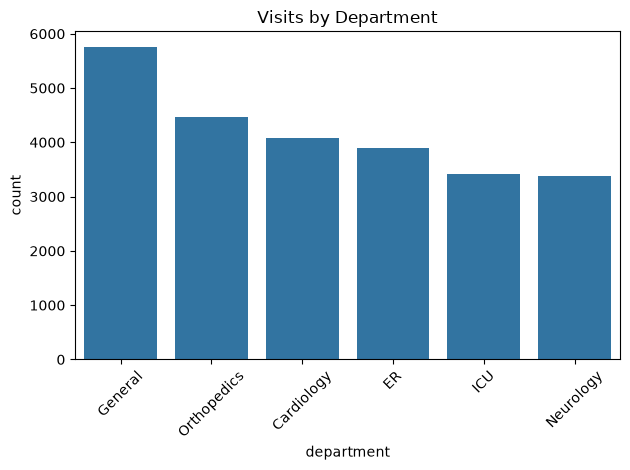

In [25]:
# Barchart showing visits by department
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

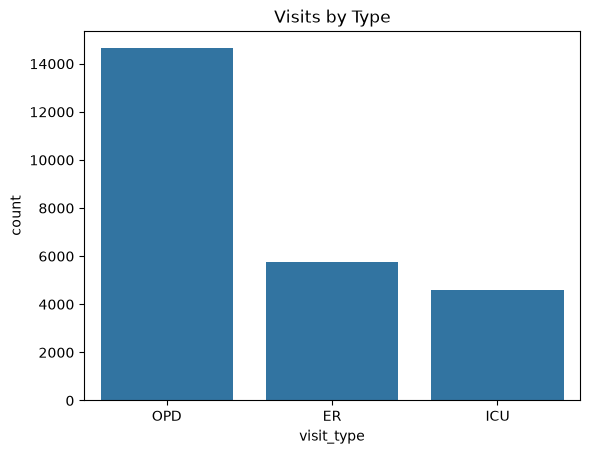

In [26]:
# Visits by Type
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

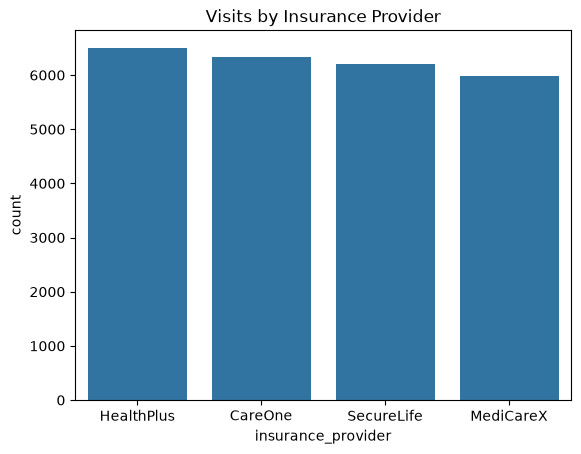

In [27]:
# Visits by Insurance Provider
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.title("Visits by Insurance Provider")
plt.show()

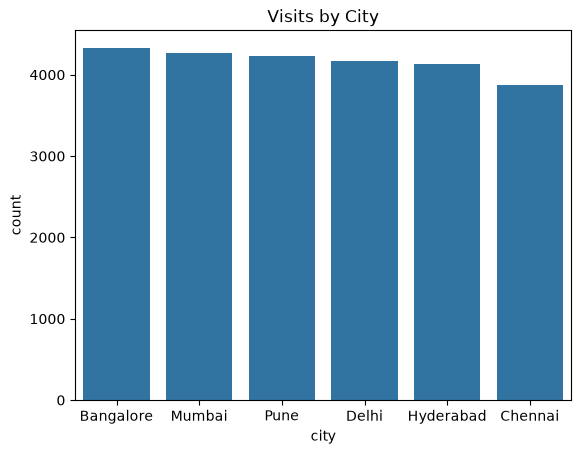

In [28]:
# Visits by City
sns.countplot(data=df, x="city", order=df["city"].value_counts().index)
plt.title("Visits by City")
plt.show()

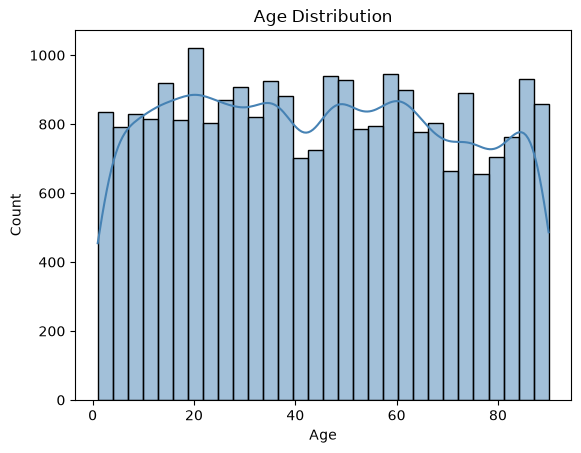

count    25000.00
mean        44.89
std         25.86
min          1.00
25%         22.00
50%         45.00
75%         67.00
max         90.00
Name: age, dtype: float64


In [29]:
# Age Dsitribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

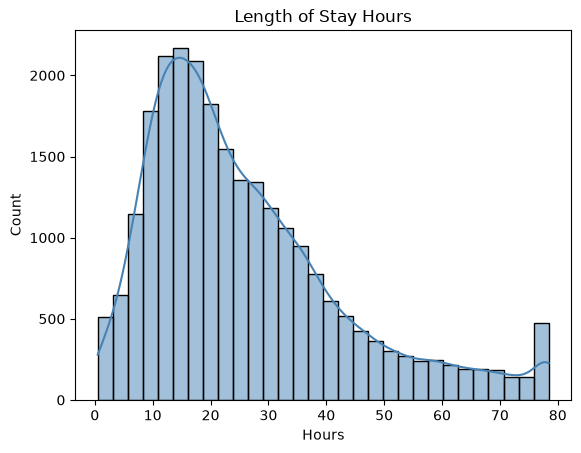

count    25000.00
mean        26.03
std         17.15
min          0.50
25%         13.54
50%         21.61
75%         34.22
max         78.42
Name: length_of_stay_hours, dtype: float64


In [30]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [31]:
# IQR = Interquartile Range - the spread of the middle 50% of your data
# 25% = 9.96  (bottom quarter boundary)
# 75% = 27.31 (top quarter boundary)
IQR = 27.31 - 9.96 
logger.info(f"IQR value: {IQR}")

[18:19:23] INFO     IQR value: 17.349999999999998                                                   ]8;id=4438733;file:///tmp/ipykernel_3060/3687607136.py\3687607136.py]8;;\:]8;id=4438734;file:///tmp/ipykernel_3060/3687607136.py#5\5]8;;\

In [32]:
# Upper Fence
# An upper fence is the cutoff, beyond which a value is considered to an outlier
# upper_fence = 75% + (1.5*IQR)
# John's variable = 1.5 (universal multiplier)

upper_fence = 27.31 + (1.5*17.35)
logger.info(f"Upper fence value: {upper_fence}")

           INFO     Upper fence value: 53.335                                                       ]8;id=4438741;file:///tmp/ipykernel_3060/4030461797.py\4030461797.py]8;;\:]8;id=4438742;file:///tmp/ipykernel_3060/4030461797.py#7\7]8;;\

## Outlier Detection

### Step 4 — Outlier Detection

Two approaches:
- **Boxplot** — visual detection
- **IQR method** — numerical calculation

**IQR = Q3 − Q1** (middle 50% of data)  
Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR  

Anything outside these bounds = outlier.

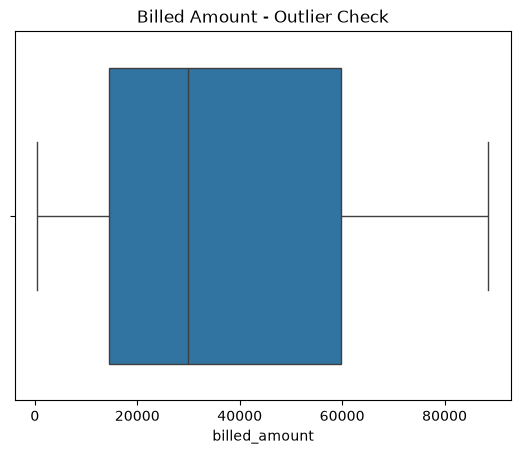

In [33]:
sns.boxplot(x=df["billed_amount"])
plt.title("Billed Amount - Outlier Check")
plt.show()

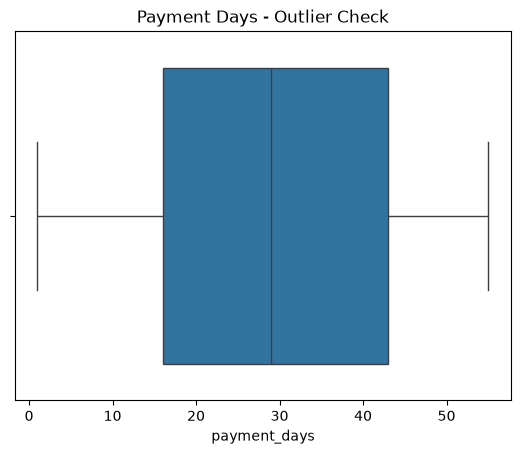

In [34]:
sns.boxplot(x=df["payment_days"])
plt.title("Payment Days - Outlier Check")
plt.show()

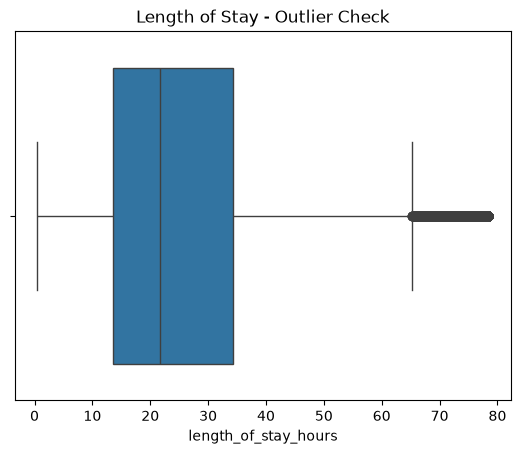

In [35]:
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stay - Outlier Check")
plt.show()

In [36]:
# IQR explicit calculation — numbers behind the boxplot
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    logger.info(f"{col}")
    logger.info(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    logger.info(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    logger.info(f"  Outliers    = {n_out} rows")
    logger.info(" ")

           INFO     length_of_stay_hours                                                           ]8;id=4438749;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438750;file:///tmp/ipykernel_3060/2470761367.py#10\10]8;;\

           INFO       Q1 = 13.5  |  Q3 = 34.2  |  IQR = 20.7                                       ]8;id=4438756;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438757;file:///tmp/ipykernel_3060/2470761367.py#11\11]8;;\

           INFO       Lower bound = -17.5  |  Upper bound = 65.2                                   ]8;id=4438763;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438764;file:///tmp/ipykernel_3060/2470761367.py#12\12]8;;\

           INFO       Outliers    = 1136 rows                                                      ]8;id=4438770;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438771;file:///tmp/ipykernel_3060/2470761367.py#13\13]8;;\

           INFO                                                                                    ]8;id=4438777;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438778;file:///tmp/ipykernel_3060/2470761367.py#14\14]8;;\

...

           INFO     payment_days                                                                   ]8;id=4438813;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438814;file:///tmp/ipykernel_3060/2470761367.py#10\10]8;;\

           INFO       Q1 = 16.0  |  Q3 = 43.0  |  IQR = 27.0                                       ]8;id=4438819;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438820;file:///tmp/ipykernel_3060/2470761367.py#11\11]8;;\

           INFO       Lower bound = -24.5  |  Upper bound = 83.5                                   ]8;id=4438825;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438826;file:///tmp/ipykernel_3060/2470761367.py#12\12]8;;\

           INFO       Outliers    = 0 rows                                                         ]8;id=4438831;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438832;file:///tmp/ipykernel_3060/2470761367.py#13\13]8;;\

           INFO                                                                                    ]8;id=4438837;file:///tmp/ipykernel_3060/2470761367.py\2470761367.py]8;;\:]8;id=4438838;file:///tmp/ipykernel_3060/2470761367.py#14\14]8;;\

## Feature Correlations

### Step 5 — Feature Correlations

We encode the target variables numerically so we can measure correlation.

- `risk_score`  → Low=0, Medium=1, High=2
- `claim_status` → Paid=0, Pending=1, Rejected=2

In [37]:
# Encode target for correlation analysis
df["risk_numeric"] = df["risk_score"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)
df["claim_numeric"] = df["claim_status"].map(
    {"Paid": 0, "Pending": 1, "Rejected": 2}
)

print("risk_numeric :",  {"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric :", {"Paid": 0, "Pending": 1, "Rejected": 2})

risk_numeric : {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric : {'Paid': 0, 'Pending': 1, 'Rejected': 2}


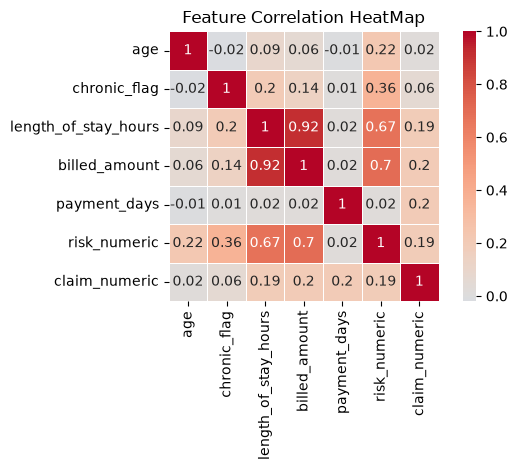

In [38]:
# Full corrleation heatmap
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=0.5, square=True)
plt.title("Feature Correlation HeatMap")
plt.tight_layout()
plt.show()

In [39]:
# What correlates with risk_score?
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
billed_amount           0.70
length_of_stay_hours    0.67
chronic_flag            0.36
age                     0.22
claim_numeric           0.19
payment_days            0.02
Name: risk_numeric, dtype: float64


In [40]:
# What correlates with claim_status?
corr_claim = corr["claim_numeric"].drop("claim_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
payment_days            0.20
billed_amount           0.20
length_of_stay_hours    0.19
risk_numeric            0.19
chronic_flag            0.06
age                     0.02
Name: claim_numeric, dtype: float64


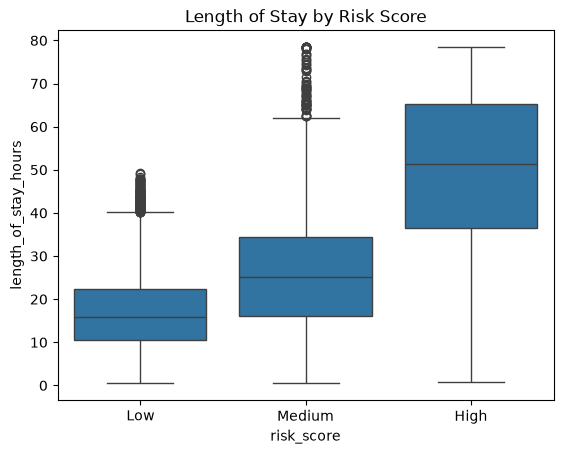


Mean LOS by Risk Score:
risk_score
High      50.69
Low       16.92
Medium    26.10
Name: length_of_stay_hours, dtype: float64


In [41]:
# LOS by risk score — the most important relationship
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",
            order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()

print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
      .mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
CareOne       25.7
MediCareX     24.3
HealthPlus    18.7
SecureLife    15.7
Name: is_rejected, dtype: float64


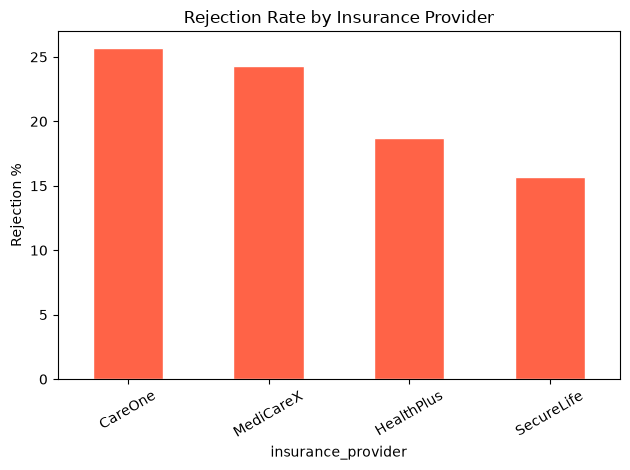

In [42]:
# Rejection rate by insurance provider
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Class Imbalance Deep Dive

### Step 6 — Class Imbalance & Class Collapse Demo

**Class imbalance** = one class has significantly more rows than others.

**Class collapse** = the model ignores minority classes and predicts 
only the majority class — achieving decent accuracy by being lazy.

We will prove this live with a before/after demo.

In [43]:
# Naive baseline - what happens if we always predict majority class

most_common = df["risk_score"].mode()[0]
naive_acc = (df["risk_score"] == most_common).mean()
print(f"Majority class: '{most_common}'") 
print(f"Naive Accuracy: '{naive_acc:.1%}'")

Majority class: 'Low'
Naive Accuracy: '46.9%'


In [44]:
# Demo setup - two features only, to keep it clean
X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000, random_state=42) # Creating the brain
model_bad.fit(X_demo, y_demo) # Training the brain
pred_bad = model_bad.predict(X_demo) # Using the brain
logger.warning("Without class_weight='balanced':")
logger.info("-"*45)
logger.info(classification_report(y_demo, pred_bad))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

[18:19:24] WARNING  Without class_weight='balanced':                                                ]8;id=4438845;file:///tmp/ipykernel_3060/2734165953.py\2734165953.py]8;;\:]8;id=4438846;file:///tmp/ipykernel_3060/2734165953.py#9\9]8;;\

           INFO     ---------------------------------------------                                  ]8;id=4438852;file:///tmp/ipykernel_3060/2734165953.py\2734165953.py]8;;\:]8;id=4438853;file:///tmp/ipykernel_3060/2734165953.py#10\10]8;;\

           INFO                   precision    recall  f1-score   support                          ]8;id=4438859;file:///tmp/ipykernel_3060/2734165953.py\2734165953.py]8;;\:]8;id=4438860;file:///tmp/ipykernel_3060/2734165953.py#11\11]8;;\
                                                                                                                   
                            High       0.78      0.63      0.69      4316                                          
                             Low       0.72      0.78      0.75     11735                                          
                          Medium       0.56      0.55      0.56      8949                                          
                                                                                                                   
                        accuracy                           0.67     25000                                          
                       macro avg       0.69      0.65      0.67     25000                                          
                    weighted avg       0.67      0.67      0.67     25000                                          
                                                                                                                   

In [45]:
# Demo setup - two features only, to keep it clean
#X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
#y_demo = df["risk_score"]

# without class weight
model_good = LogisticRegression(max_iter=1000,class_weight="balanced", random_state=42) # Creating the brain
model_good.fit(X_demo, y_demo) # Training the brain
pred_good = model_good.predict(X_demo) # Using the brain
print("With class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_good))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

With class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.62      0.74      0.67      4316
         Low       0.76      0.71      0.73     11735
      Medium       0.54      0.54      0.54      8949

    accuracy                           0.65     25000
   macro avg       0.64      0.66      0.65     25000
weighted avg       0.66      0.65      0.65     25000



In [46]:
from sklearn.metrics import recall_score

# Before — random labels (from earlier in notebook)
# After  — clinical labels (current)

recall_high_no_weight  = recall_score(y_demo, pred_bad,
                            labels=["High"], average=None)[0]
recall_high_balanced   = recall_score(y_demo, pred_good,
                            labels=["High"], average=None)[0]

logger.info("HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA")
logger.info("-" * 45)
logger.info(f"Without class_weight : {recall_high_no_weight:.0%}")
logger.info(f"With class_weight    : {recall_high_balanced:.0%}")
logger.info(" ")
logger.info("COMPARISON — OLD vs NEW DATASET (with class_weight)")
logger.info("-" * 45)
logger.info(f"Old dataset (random labels)  : ~20%  accuracy 37%")
logger.info(f"New dataset (clinical labels): {recall_high_balanced:.0%}  accuracy 67%")
logger.info("")
logger.info("Same model. Same 2 features. Labels fixed.")
logger.info("30 percentage point accuracy jump from data quality alone.")

           INFO     HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA                                  ]8;id=4438867;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438868;file:///tmp/ipykernel_3060/502581120.py#11\11]8;;\

           INFO     ---------------------------------------------                                   ]8;id=4438874;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438875;file:///tmp/ipykernel_3060/502581120.py#12\12]8;;\

           INFO     Without class_weight : 63%                                                      ]8;id=4438881;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438882;file:///tmp/ipykernel_3060/502581120.py#13\13]8;;\

           INFO     With class_weight    : 74%                                                      ]8;id=4438888;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438889;file:///tmp/ipykernel_3060/502581120.py#14\14]8;;\

           INFO                                                                                     ]8;id=4438895;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438896;file:///tmp/ipykernel_3060/502581120.py#15\15]8;;\

...

           INFO     Old dataset (random labels)  : ~20%  accuracy 37%                               ]8;id=4438916;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438917;file:///tmp/ipykernel_3060/502581120.py#18\18]8;;\

           INFO     New dataset (clinical labels): 74%  accuracy 67%                                ]8;id=4438923;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438924;file:///tmp/ipykernel_3060/502581120.py#19\19]8;;\

           INFO                                                                                     ]8;id=4438930;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438931;file:///tmp/ipykernel_3060/502581120.py#20\20]8;;\

           INFO     Same model. Same 2 features. Labels fixed.                                      ]8;id=4438937;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438938;file:///tmp/ipykernel_3060/502581120.py#21\21]8;;\

           INFO     30 percentage point accuracy jump from data quality alone.                      ]8;id=4438944;file:///tmp/ipykernel_3060/502581120.py\502581120.py]8;;\:]8;id=4438945;file:///tmp/ipykernel_3060/502581120.py#22\22]8;;\

## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [47]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,2,2026-01-01,2025-12-27,5
1,12,2026-01-01,2025-08-13,141
2,129,2026-01-01,2025-07-20,165
3,133,2026-01-01,2025-11-02,60
4,139,2026-01-01,2025-02-05,330


In [48]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)

,patient_id,visit_frequency
0,2,4
1,12,8
2,129,3
3,133,3
4,139,9
5,170,6
6,216,5
7,222,5
8,243,9
9,335,5


In [49]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,2,9.63,21.120000
1,12,59.60,23.750000
2,129,59.28,32.460000
3,133,25.15,30.056667
4,139,42.88,29.030000


In [50]:
 # Provider rejection rate
# is_rejected already created in Cell 37
df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

logger.info("Rejection rate per provider:")
logger.info(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

           INFO     Rejection rate per provider:                                                    ]8;id=4438952;file:///tmp/ipykernel_3060/2211178042.py\2211178042.py]8;;\:]8;id=4438953;file:///tmp/ipykernel_3060/2211178042.py#5\5]8;;\

           INFO     insurance_provider                                                              ]8;id=4438959;file:///tmp/ipykernel_3060/2211178042.py\2211178042.py]8;;\:]8;id=4438960;file:///tmp/ipykernel_3060/2211178042.py#6\6]8;;\
                    CareOne       0.257                                                                            
                    HealthPlus    0.187                                                                            
                    MediCareX     0.243                                                                            
                    SecureLife    0.157                                                                            
                    Name: provider_rejection_rate, dtype: float64                                                  

In [51]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2026-01-01,1,3
1,2026-01-01,1,3
2,2026-01-01,1,3
3,2026-01-01,1,3
4,2026-01-01,1,3


In [52]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

logger.info(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
logger.info("")
logger.info(df["high_cost_visit_flag"].value_counts())

           INFO     High cost threshold (75th percentile): ₹59,711                                  ]8;id=4438967;file:///tmp/ipykernel_3060/1502611897.py\1502611897.py]8;;\:]8;id=4438968;file:///tmp/ipykernel_3060/1502611897.py#5\5]8;;\

           INFO                                                                                     ]8;id=4438974;file:///tmp/ipykernel_3060/1502611897.py\1502611897.py]8;;\:]8;id=4438975;file:///tmp/ipykernel_3060/1502611897.py#6\6]8;;\

           INFO     high_cost_visit_flag                                                            ]8;id=4438981;file:///tmp/ipykernel_3060/1502611897.py\1502611897.py]8;;\:]8;id=4438982;file:///tmp/ipykernel_3060/1502611897.py#7\7]8;;\
                    0    18750                                                                                     
                    1     6250                                                                                     
                    Name: count, dtype: int64                                                                      

In [53]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

logger.info("New features added:")
for f in new_features:
    logger.info(f"  ✓ {f}")

logger.info(f"\nFinal dataset shape: {df.shape}")

           INFO     New features added:                                                              ]8;id=4438989;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4438990;file:///tmp/ipykernel_3060/83191368.py#12\12]8;;\

           INFO       ✓ days_since_registration                                                      ]8;id=4438996;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4438997;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ visit_frequency                                                              ]8;id=4439002;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439003;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ avg_los_per_patient                                                          ]8;id=4439008;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439009;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ provider_rejection_rate                                                      ]8;id=4439014;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439015;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ visit_month                                                                  ]8;id=4439020;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439021;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ visit_dayofweek                                                              ]8;id=4439026;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439027;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO       ✓ high_cost_visit_flag                                                         ]8;id=4439032;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439033;file:///tmp/ipykernel_3060/83191368.py#14\14]8;;\

           INFO                                                                                      ]8;id=4439039;file:///tmp/ipykernel_3060/83191368.py\83191368.py]8;;\:]8;id=4439040;file:///tmp/ipykernel_3060/83191368.py#16\16]8;;\
                    Final dataset shape: (25000, 30)                                                               

In [54]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,91.66,6.04,26.03,0.21,7.57,2.98,0.25
std,80.65,2.39,8.48,0.04,4.10,2.02,0.43
min,1.00,1.00,0.50,0.16,1.00,0.00,0.00
25%,25.00,4.00,20.06,0.19,4.00,1.00,0.00
50%,69.00,6.00,25.13,0.19,9.00,3.00,0.00
75%,140.00,8.00,30.82,0.26,11.00,5.00,0.25
max,363.00,14.00,78.42,0.26,12.00,6.00,1.00


In [55]:
# Save enriched model_table — ready for Phase 3 Modeling
df.to_csv("../outputs/model_table.csv", index=False)

logger.info("model_table.csv saved ✓")
logger.info(f"Shape  : {df.shape}")
logger.info(f"Columns: {df.columns.tolist()}")
logger.info("\nReady for Phase 3 — Modeling")

[18:19:25] INFO     model_table.csv saved ✓                                                         ]8;id=4439047;file:///tmp/ipykernel_3060/2010981405.py\2010981405.py]8;;\:]8;id=4439048;file:///tmp/ipykernel_3060/2010981405.py#4\4]8;;\

           INFO     Shape  : (25000, 30)                                                            ]8;id=4439054;file:///tmp/ipykernel_3060/2010981405.py\2010981405.py]8;;\:]8;id=4439055;file:///tmp/ipykernel_3060/2010981405.py#5\5]8;;\

           INFO     Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider',          ]8;id=4439061;file:///tmp/ipykernel_3060/2010981405.py\2010981405.py]8;;\:]8;id=4439062;file:///tmp/ipykernel_3060/2010981405.py#6\6]8;;\
                    'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department',                   
                    'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id',                    
                    'billed_amount', 'approved_amount', 'claim_status', 'payment_days',                            
                    'billing_date', 'risk_numeric', 'claim_numeric', 'is_rejected',                                
                    'days_since_registration', 'visit_frequency', 'avg_los_per_patient',                           
                    'provider_rejection_rate', 'visit_month', 'visit_dayofweek',                                   
                    'high_cost_visit_flag']                                                                        

           INFO                                                                                     ]8;id=4439068;file:///tmp/ipykernel_3060/2010981405.py\2010981405.py]8;;\:]8;id=4439069;file:///tmp/ipykernel_3060/2010981405.py#7\7]8;;\
                    Ready for Phase 3 — Modeling                                                                   

# Phase 3 — Machine Learning Modeling
## Healthcare AI System

**Input:**  `outputs/model_table.csv` — 25,000 rows  
**Output:** 
- `models/risk_model.joblib`  
- `models/claim_model.joblib`  
- `outputs/feature_schema.json`

**Two Models:**
- **Model A** — Visit Risk Classification (Low / Medium / High)
- **Model B** — Claim Outcome Prediction (Paid / Pending / Rejected)

In [56]:
# Imports
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             f1_score)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

logger.info("Imports done ✓")

           INFO     Imports done ✓                                                                 ]8;id=4439076;file:///tmp/ipykernel_3060/3750449554.py\3750449554.py]8;;\:]8;id=4439077;file:///tmp/ipykernel_3060/3750449554.py#22\22]8;;\

## Model A — Visit Risk Classification

**Business Purpose:**  
Predict whether a hospital visit represents Low, Medium,
or High operational and clinical risk.

**Target:** `risk_score` — Low / Medium / High  
**Split:**  Time-based — earliest 80% train, latest 20% test  
**Why time-based?** Prevents data leakage from future visits
influencing predictions on past visits.

In [57]:
# Step 1) Load the dataset
df = pd.read_csv("../outputs/model_table.csv", parse_dates=["registration_date", "visit_date", "billing_date"])
print("Shape:", df.shape)
df.head()



Shape: (25000, 30)


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,...,risk_numeric,claim_numeric,is_rejected,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
0,2,15,F,Mumbai,CareOne,0,2025-12-27,8,2026-01-01,General,...,0,2,1,5,4,21.120000,0.256876,1,3,0
1,12,3,M,Bangalore,CareOne,0,2025-08-13,65,2026-01-01,ICU,...,2,2,1,141,8,23.750000,0.256876,1,3,1
2,129,44,M,Pune,MediCareX,1,2025-07-20,651,2026-01-01,ICU,...,2,1,0,165,3,32.460000,0.242556,1,3,1
3,133,47,F,Delhi,CareOne,1,2025-11-02,670,2026-01-01,General,...,1,0,0,60,3,30.056667,0.256876,1,3,0
4,139,14,F,Chennai,SecureLife,1,2025-02-05,706,2026-01-01,Cardiology,...,1,0,0,330,9,29.030000,0.157496,1,3,1


In [58]:
# Step 2) risk features
risk_target = "risk_score"

risk_features = [
    "age",
    "gender",
    "city",
    "insurance_provider",
    "chronic_flag",
    "department",
    "visit_type",
    "doctor_id",
    "length_of_stay_hours",
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "visit_month",
    "visit_dayofweek"
]
risk_df = df[risk_features + [risk_target, "visit_date"]].copy()
risk_df = risk_df.dropna(subset=[risk_target, "visit_date"])
logger.info("Risk dataset shape: {}".format(risk_df.shape))
risk_df.head()

           INFO     Risk dataset shape: (25000, 16)                                                ]8;id=4439084;file:///tmp/ipykernel_3060/2171615362.py\2171615362.py]8;;\:]8;id=4439085;file:///tmp/ipykernel_3060/2171615362.py#22\22]8;;\

,age,gender,city,insurance_provider,chronic_flag,department,visit_type,doctor_id,length_of_stay_hours,days_since_registration,visit_frequency,avg_los_per_patient,visit_month,visit_dayofweek,risk_score,visit_date
0,15,F,Mumbai,CareOne,0,General,OPD,105,9.63,5,4,21.120000,1,3,Low,2026-01-01
1,3,M,Bangalore,CareOne,0,ICU,ICU,112,59.60,141,8,23.750000,1,3,High,2026-01-01
2,44,M,Pune,MediCareX,1,ICU,ER,150,59.28,165,3,32.460000,1,3,High,2026-01-01
3,47,F,Delhi,CareOne,1,General,OPD,145,25.15,60,3,30.056667,1,3,Medium,2026-01-01
4,14,F,Chennai,SecureLife,1,Cardiology,ER,148,42.88,330,9,29.030000,1,3,Medium,2026-01-01


In [59]:
# Step 3) Time-Based split
risk_df = risk_df.sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(risk_df)*0.8)

risk_train = risk_df.iloc[:split_idx].copy()
risk_test = risk_df.iloc[split_idx:].copy()

X_train_risk = risk_train[risk_features]
X_test_risk = risk_test[risk_features]

y_train_risk = risk_train[risk_target]
y_test_risk = risk_test[risk_target]

logger.info("Train shape: {}".format(X_train_risk.shape))
logger.info("Test shape: {}".format(X_test_risk.shape))
logger.info("Train Period: {} -> {}".format(risk_train["visit_date"].min().date(), risk_train["visit_date"].max().date()))
logger.info("Test Period: {} -> {}".format(risk_test["visit_date"].min().date(), risk_test["visit_date"].max().date()))

           INFO     Train shape: (20000, 14)                                                       ]8;id=4439092;file:///tmp/ipykernel_3060/1526459602.py\1526459602.py]8;;\:]8;id=4439093;file:///tmp/ipykernel_3060/1526459602.py#14\14]8;;\

           INFO     Test shape: (5000, 14)                                                         ]8;id=4439099;file:///tmp/ipykernel_3060/1526459602.py\1526459602.py]8;;\:]8;id=4439100;file:///tmp/ipykernel_3060/1526459602.py#15\15]8;;\

           INFO     Train Period: 2025-01-21 -> 2026-01-02                                         ]8;id=4439106;file:///tmp/ipykernel_3060/1526459602.py\1526459602.py]8;;\:]8;id=4439107;file:///tmp/ipykernel_3060/1526459602.py#16\16]8;;\

           INFO     Test Period: 2026-01-02 -> 2026-01-20                                          ]8;id=4439113;file:///tmp/ipykernel_3060/1526459602.py\1526459602.py]8;;\:]8;id=4439114;file:///tmp/ipykernel_3060/1526459602.py#17\17]8;;\

### Preprocessing Pipeline

Two transformers:
- **Numeric** → SimpleImputer (median strategy)
- **Categorical** → SimpleImputer + OneHotEncoder

Combined using ColumnTransformer.
This entire pipeline gets saved with the model — 
no separate preprocessing step at inference time.

In [60]:
# Step 4) Preprocessing Pipeline
risk_numeric_features = [
    "age", "chronic_flag", "length_of_stay_hours",
    "days_since_registration", "visit_frequency",
    "doctor_id", "avg_los_per_patient",
    "visit_month", "visit_dayofweek"
]

risk_categorical_features = [
    "gender", "city", "insurance_provider",
    "department", "visit_type"
]

risk_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

risk_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

risk_preprocessor = ColumnTransformer(transformers=[
    ("num", risk_numeric_transformer,    risk_numeric_features),
    ("cat", risk_categorical_transformer, risk_categorical_features)
])

logger.info("Preprocessing pipeline ready ✓")

           INFO     Preprocessing pipeline ready ✓                                                 ]8;id=4439121;file:///tmp/ipykernel_3060/2289497899.py\2289497899.py]8;;\:]8;id=4439122;file:///tmp/ipykernel_3060/2289497899.py#28\28]8;;\

### Baseline Model: Logistic Regression

We always start with the simplest model.
Logistic Regression gives us a baseline to beat.
`class_weight='balanced'` — handles class imbalance
as proven in Phase 2 EDA.

In [61]:
# Step 5) Logistic Regression Model
risk_baseline_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", LogisticRegression(
        max_iter = 1000,
        class_weight="balanced"
    ))
])

# Train
risk_baseline_model.fit(X_train_risk, y_train_risk)

# Predict
risk_baseline_pred_train = risk_baseline_model.predict(X_train_risk)
risk_baseline_pred_test =  risk_baseline_model.predict(X_test_risk)

baseline_acc = accuracy_score(y_test_risk, risk_baseline_pred_test)
logger.info("Risk Baseline Train Accuracy : {}".format(round(accuracy_score(y_train_risk, risk_baseline_pred_train), 4)))
logger.info("Risk Baseline Test Accuracy  : {}".format(round(accuracy_score(y_test_risk,  risk_baseline_pred_test), 4)))
logger.info("Risk Baseline Test Weighted F1: {}".format(round(f1_score(y_test_risk, risk_baseline_pred_test, average="weighted"), 4)))
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_risk, risk_baseline_pred_test))
logger.info("Confusion Matrix:\n {}".format(confusion_matrix(y_test_risk, risk_baseline_pred_test)))

[18:19:26] INFO     Risk Baseline Train Accuracy : 0.9233                                           ]8;id=4439129;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439130;file:///tmp/ipykernel_3060/760001067.py#18\18]8;;\

           INFO     Risk Baseline Test Accuracy  : 0.9218                                           ]8;id=4439136;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439137;file:///tmp/ipykernel_3060/760001067.py#19\19]8;;\

           INFO     Risk Baseline Test Weighted F1: 0.9221                                          ]8;id=4439143;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439144;file:///tmp/ipykernel_3060/760001067.py#20\20]8;;\

           INFO                                                                                     ]8;id=4439150;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439151;file:///tmp/ipykernel_3060/760001067.py#21\21]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                           ]8;id=4439157;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439158;file:///tmp/ipykernel_3060/760001067.py#22\22]8;;\
                                                                                                                   
                            High       0.91      0.95      0.93       838                                          
                             Low       0.96      0.93      0.94      2360                                          
                          Medium       0.88      0.91      0.89      1802                                          
                                                                                                                   
                        accuracy                           0.92      5000                                          
                       macro avg       0.92      0.93      0.92      5000                                          
                    weighted avg       0.92      0.92      0.92      5000                                          
                                                                                                                   

[18:19:27] INFO     Confusion Matrix:                                                               ]8;id=4439164;file:///tmp/ipykernel_3060/760001067.py\760001067.py]8;;\:]8;id=4439165;file:///tmp/ipykernel_3060/760001067.py#23\23]8;;\
                     [[ 794    0   44]                                                                             
                     [   0 2184  176]                                                                              
                     [  78   93 1631]]                                                                             

### Advanced Model: Random Forest

Random Forest captures **non-linear interactions** across
patient, department, and visit characteristics.

Logistic Regression assumes linear relationships.
Hospital risk is rarely linear —
a 70-year-old chronic ICU patient is not just
the sum of those individual risk factors.

Key parameters:
- `class_weight='balanced_subsample'` — balances per tree
- `max_depth=8` — prevents overfitting
- `min_samples_leaf=10` — minimum samples at leaf node

Example:
- Doctor 1  →  High
- Doctor 2  →  High
- Doctor 3  →  Medium
- Doctor 4  →  High
- ...
Final vote  →  High  ✅

In [62]:
# Step 6) Random Forest Model
risk_rf_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42
    ))
])

risk_rf_model.fit(X_train_risk, y_train_risk)

risk_rf_pred_train = risk_rf_model.predict(X_train_risk)
risk_rf_pred_test  = risk_rf_model.predict(X_test_risk)

rf_acc = accuracy_score(y_test_risk, risk_rf_pred_test)

logger.info("Risk RF Train Accuracy : {}".format(round(accuracy_score(y_train_risk, risk_rf_pred_train), 4)))
logger.info("Risk RF Test Accuracy  : {}".format(round(accuracy_score(y_test_risk,  risk_rf_pred_test),  4)))
logger.info("Risk RF Test Weighted F1: {}".format(round(f1_score(y_test_risk, risk_rf_pred_test, average="weighted"), 4)))
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_risk, risk_rf_pred_test))
logger.info("Confusion Matrix:\n {}".format(confusion_matrix(y_test_risk, risk_rf_pred_test)))



[18:19:28] INFO     Risk RF Train Accuracy : 0.9414                                                ]8;id=4439172;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439173;file:///tmp/ipykernel_3060/3491282266.py#21\21]8;;\

           INFO     Risk RF Test Accuracy  : 0.935                                                 ]8;id=4439179;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439180;file:///tmp/ipykernel_3060/3491282266.py#22\22]8;;\

           INFO     Risk RF Test Weighted F1: 0.935                                                ]8;id=4439186;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439187;file:///tmp/ipykernel_3060/3491282266.py#23\23]8;;\

           INFO                                                                                    ]8;id=4439193;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439194;file:///tmp/ipykernel_3060/3491282266.py#24\24]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                          ]8;id=4439200;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439201;file:///tmp/ipykernel_3060/3491282266.py#25\25]8;;\
                                                                                                                   
                            High       0.95      0.93      0.94       838                                          
                             Low       0.95      0.95      0.95      2360                                          
                          Medium       0.91      0.91      0.91      1802                                          
                                                                                                                   
                        accuracy                           0.94      5000                                          
                       macro avg       0.94      0.93      0.93      5000                                          
                    weighted avg       0.94      0.94      0.94      5000                                          
                                                                                                                   

           INFO     Confusion Matrix:                                                              ]8;id=4439207;file:///tmp/ipykernel_3060/3491282266.py\3491282266.py]8;;\:]8;id=4439208;file:///tmp/ipykernel_3060/3491282266.py#26\26]8;;\
                     [[ 779    0   59]                                                                             
                     [   0 2253  107]                                                                              
                     [  44  115 1643]]                                                                             

### XGBoost Model

XGBoost uses **gradient boosting** — builds trees sequentially,
each correcting the errors of the previous one.

Why XGBoost here:
- Handles mixed numeric + categorical features well
- Built-in regularisation prevents overfitting
- Typically outperforms Random Forest on structured tabular data

**Note:** XGBoost requires numeric labels.
We use LabelEncoder to convert Low/Medium/High → 0/1/2.
We keep separate variables (y_train_risk_xgb / y_test_risk_xgb)
so LR and RF evaluations above are not affected.

In [63]:
# Encode target for XGBoost only
le = LabelEncoder()
risk_df["risk_score_encoded"] = le.fit_transform(risk_df["risk_score"])
logger.info("Label Mapping: {}".format(dict(zip(le.classes_, le.transform(le.classes_)))))

           INFO     Label Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)} ]8;id=4439215;file:///tmp/ipykernel_3060/3422707964.py\3422707964.py]8;;\:]8;id=4439216;file:///tmp/ipykernel_3060/3422707964.py#4\4]8;;\

In [64]:
# Time-based split for XGBoost
# Using same split_idx — consistent with LR and RF
risk_df = risk_df.sort_values("visit_date").reset_index(drop=True)
split_idx = int(len(risk_df) * 0.8)

risk_train_xgb = risk_df.iloc[:split_idx].copy()
risk_test_xgb  = risk_df.iloc[split_idx:].copy()

X_train_risk = risk_train_xgb[risk_features]
X_test_risk  = risk_test_xgb[risk_features]

# Separate XGB label variables — does NOT overwrite y_train_risk
y_train_risk_xgb = risk_train_xgb["risk_score_encoded"]
y_test_risk_xgb  = risk_test_xgb["risk_score_encoded"]

print("XGBoost train shape:", X_train_risk.shape)
print("XGBoost test shape :", X_test_risk.shape)

XGBoost train shape: (20000, 14)
XGBoost test shape : (5000, 14)


In [65]:
# Step 7) XGBoost Model
risk_xgb_model = Pipeline(steps=[
    ("preprocessor", risk_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train → Predict → Evaluate
# Train
risk_xgb_model.fit(X_train_risk, y_train_risk_xgb)

# Predict Train
risk_xgb_pred_train = risk_xgb_model.predict(X_train_risk)
# Predict Test
risk_xgb_pred_test  = risk_xgb_model.predict(X_test_risk)

# Save for comparison
xgb_acc = accuracy_score(y_test_risk_xgb, risk_xgb_pred_test)

logger.info(f"Risk XGB Train Accuracy : {round(accuracy_score(y_train_risk_xgb, risk_xgb_pred_train), 4)}")
logger.info(f"Risk XGB Test Accuracy  : {round(accuracy_score(y_test_risk_xgb, risk_xgb_pred_test), 4)}")
logger.info(f"Risk XGB Test Weighted F1: {round(f1_score(y_test_risk_xgb, risk_xgb_pred_test, average='weighted'), 4)}")
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_risk_xgb, risk_xgb_pred_test,
                             target_names=le.classes_))
logger.info(f"Confusion Matrix:\n {confusion_matrix(y_test_risk_xgb, risk_xgb_pred_test)}")

[18:19:30] INFO     Risk XGB Train Accuracy : 0.9946                                               ]8;id=4439223;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439224;file:///tmp/ipykernel_3060/2969485392.py#29\29]8;;\

           INFO     Risk XGB Test Accuracy  : 0.9546                                               ]8;id=4439230;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439231;file:///tmp/ipykernel_3060/2969485392.py#30\30]8;;\

           INFO     Risk XGB Test Weighted F1: 0.9547                                              ]8;id=4439237;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439238;file:///tmp/ipykernel_3060/2969485392.py#31\31]8;;\

           INFO                                                                                    ]8;id=4439244;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439245;file:///tmp/ipykernel_3060/2969485392.py#32\32]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                          ]8;id=4439251;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439252;file:///tmp/ipykernel_3060/2969485392.py#33\33]8;;\
                                                                                                                   
                            High       0.98      0.94      0.96       840                                          
                             Low       0.97      0.96      0.97      2360                                          
                          Medium       0.93      0.95      0.94      1800                                          
                                                                                                                   
                        accuracy                           0.95      5000                                          
                       macro avg       0.96      0.95      0.95      5000                                          
                    weighted avg       0.96      0.95      0.95      5000                                          
                                                                                                                   

           INFO     Confusion Matrix:                                                              ]8;id=4439258;file:///tmp/ipykernel_3060/2969485392.py\2969485392.py]8;;\:]8;id=4439259;file:///tmp/ipykernel_3060/2969485392.py#35\35]8;;\
                     [[ 789    0   51]                                                                             
                     [   0 2276   84]                                                                              
                     [  15   77 1708]]                                                                             

In [66]:
# Random vs XBoost Model Comparison
logger.info("=" * 45)
logger.info("MODEL A — RISK CLASSIFICATION COMPARISON")
logger.info("=" * 45)
logger.info(f"Logistic Regression : {baseline_acc:.4f}")
logger.info(f"Random Forest       : {rf_acc:.4f}")
logger.info(f"XGBoost             : {xgb_acc:.4f}")
logger.info( " ")
logger.info(f"Best model: XGBoost → {max(baseline_acc, rf_acc, xgb_acc):.4f}")

           INFO     =============================================                                    ]8;id=4439266;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439267;file:///tmp/ipykernel_3060/875308115.py#2\2]8;;\

           INFO     MODEL A — RISK CLASSIFICATION COMPARISON                                         ]8;id=4439273;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439274;file:///tmp/ipykernel_3060/875308115.py#3\3]8;;\

           INFO     =============================================                                    ]8;id=4439280;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439281;file:///tmp/ipykernel_3060/875308115.py#4\4]8;;\

           INFO     Logistic Regression : 0.9218                                                     ]8;id=4439287;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439288;file:///tmp/ipykernel_3060/875308115.py#5\5]8;;\

           INFO     Random Forest       : 0.9350                                                     ]8;id=4439294;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439295;file:///tmp/ipykernel_3060/875308115.py#6\6]8;;\

           INFO     XGBoost             : 0.9546                                                     ]8;id=4439301;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439302;file:///tmp/ipykernel_3060/875308115.py#7\7]8;;\

           INFO                                                                                      ]8;id=4439308;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439309;file:///tmp/ipykernel_3060/875308115.py#8\8]8;;\

           INFO     Best model: XGBoost → 0.9546                                                     ]8;id=4439315;file:///tmp/ipykernel_3060/875308115.py\875308115.py]8;;\:]8;id=4439316;file:///tmp/ipykernel_3060/875308115.py#9\9]8;;\

### Optional - Hyperparameter Tuning: Random Forest - Not needed at the moment

We use RandomizedSearchCV to find the best RF parameters.
`f1_weighted` is our scoring metric — not accuracy.
This ensures minority classes (High risk) are weighted properly.

In [67]:
rf_param_grid = {
    "classifier__n_estimators":   [200, 300, 400],
    "classifier__max_depth":      [8, 12, 16, None],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf":  [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    risk_rf_model,           # the pipeline to tune
    param_distributions=rf_param_grid,  # values to try
    n_iter=10,               # try only 10 random combinations
    cv=3,                    # 3-fold cross validation
    scoring="f1_weighted",   # optimise for weighted F1
    n_jobs=-1,               # use all CPU cores
    random_state=42          # reproducible random selection
)

rf_random_search.fit(X_train_risk, y_train_risk)

logger.info(f"Best Parameters: {rf_random_search.best_params_}")

[18:19:41] INFO     Best Parameters: {'classifier__n_estimators': 200,                             ]8;id=4439323;file:///tmp/ipykernel_3060/2759134369.py\2759134369.py]8;;\:]8;id=4439324;file:///tmp/ipykernel_3060/2759134369.py#20\20]8;;\
                    'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4,                         
                    'classifier__max_depth': 12}                                                                   

In [68]:
best_rf_model  = rf_random_search.best_estimator_
rf_tuned_pred  = best_rf_model.predict(X_test_risk)

logger.info(f"Tuned RF Accuracy   : {round(accuracy_score(y_test_risk, rf_tuned_pred), 4)}")
logger.info(f"Tuned RF Weighted F1: {round(f1_score(y_test_risk, rf_tuned_pred, average='weighted'), 4)}")
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_risk, rf_tuned_pred))

           INFO     Tuned RF Accuracy   : 0.435                                                     ]8;id=4439331;file:///tmp/ipykernel_3060/3155719867.py\3155719867.py]8;;\:]8;id=4439332;file:///tmp/ipykernel_3060/3155719867.py#4\4]8;;\

           INFO     Tuned RF Weighted F1: 0.3815                                                    ]8;id=4439338;file:///tmp/ipykernel_3060/3155719867.py\3155719867.py]8;;\:]8;id=4439339;file:///tmp/ipykernel_3060/3155719867.py#5\5]8;;\

           INFO                                                                                     ]8;id=4439345;file:///tmp/ipykernel_3060/3155719867.py\3155719867.py]8;;\:]8;id=4439346;file:///tmp/ipykernel_3060/3155719867.py#6\6]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                           ]8;id=4439352;file:///tmp/ipykernel_3060/3155719867.py\3155719867.py]8;;\:]8;id=4439353;file:///tmp/ipykernel_3060/3155719867.py#7\7]8;;\
                                                                                                                   
                            High       0.23      0.05      0.08       838                                          
                             Low       0.47      0.74      0.57      2360                                          
                          Medium       0.36      0.22      0.27      1802                                          
                                                                                                                   
                        accuracy                           0.43      5000                                          
                       macro avg       0.35      0.33      0.31      5000                                          
                    weighted avg       0.39      0.43      0.38      5000                                          
                                                                                                                   

In [69]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
# Train on past → validate on future — every fold
# Fold 1: train Jan-Apr,  validate May
# Fold 2: train Jan-Jul,  validate Aug
# Fold 3: train Jan-Oct,  validate Nov

---
## Model B — Claim Outcome Prediction

**Business Purpose:**  
Predict whether an insurance claim will be Paid, Pending,
or Rejected — before submission.

**Target:** `claim_status` — Paid / Pending / Rejected  
**Split:**  Time-based on `billing_date`

**Leakage prevention:**  
`approved_amount` and `payment_days` excluded —
both are post-outcome variables that are only known
AFTER the claim is processed.

In [70]:
# Step 1) Define Claim Features
claim_target = "claim_status"

claim_features = [
    "age",
    "gender",
    "city",
    "insurance_provider",
    "chronic_flag",
    "department",
    "visit_type",
    "doctor_id",
    "length_of_stay_hours",
    "risk_score",
    "billed_amount",
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

claim_df = df[claim_features + [claim_target, "billing_date"]].copy()
claim_df = claim_df.dropna(subset=[claim_target, "billing_date"])
logger.info(f"Claim Dataset Shape: {claim_df.shape}")
claim_df.head()

           INFO     Claim Dataset Shape: (25000, 20)                                               ]8;id=4439360;file:///tmp/ipykernel_3060/1460532591.py\1460532591.py]8;;\:]8;id=4439361;file:///tmp/ipykernel_3060/1460532591.py#27\27]8;;\

,age,gender,city,insurance_provider,chronic_flag,department,visit_type,doctor_id,length_of_stay_hours,risk_score,billed_amount,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag,claim_status,billing_date
0,15,F,Mumbai,CareOne,0,General,OPD,105,9.63,Low,9612.77,5,4,21.120000,0.256876,1,3,0,Rejected,2026-01-19
1,3,M,Bangalore,CareOne,0,ICU,ICU,112,59.60,High,88539.01,141,8,23.750000,0.256876,1,3,1,Rejected,2026-01-05
2,44,M,Pune,MediCareX,1,ICU,ER,150,59.28,High,88539.01,165,3,32.460000,0.242556,1,3,1,Pending,2026-01-20
3,47,F,Delhi,CareOne,1,General,OPD,145,25.15,Medium,20958.52,60,3,30.056667,0.256876,1,3,0,Paid,2026-01-15
4,14,F,Chennai,SecureLife,1,Cardiology,ER,148,42.88,Medium,74921.48,330,9,29.030000,0.157496,1,3,1,Paid,2026-01-16


In [71]:
# Step 2) Claim status distribution
logger.info("Claim Status Distribution")
logger.info(claim_df[claim_target].value_counts())
logger.info("")
logger.info("Claim Status % Distribution")
logger.info((claim_df[claim_target].value_counts(normalize=True) * 100).round(2))


           INFO     Claim Status Distribution                                                       ]8;id=4439368;file:///tmp/ipykernel_3060/1011270072.py\1011270072.py]8;;\:]8;id=4439369;file:///tmp/ipykernel_3060/1011270072.py#2\2]8;;\

           INFO     claim_status                                                                    ]8;id=4439375;file:///tmp/ipykernel_3060/1011270072.py\1011270072.py]8;;\:]8;id=4439376;file:///tmp/ipykernel_3060/1011270072.py#3\3]8;;\
                    Paid        13638                                                                              
                    Pending      6096                                                                              
                    Rejected     5266                                                                              
                    Name: count, dtype: int64                                                                      

           INFO                                                                                     ]8;id=4439382;file:///tmp/ipykernel_3060/1011270072.py\1011270072.py]8;;\:]8;id=4439383;file:///tmp/ipykernel_3060/1011270072.py#4\4]8;;\

           INFO     Claim Status % Distribution                                                     ]8;id=4439389;file:///tmp/ipykernel_3060/1011270072.py\1011270072.py]8;;\:]8;id=4439390;file:///tmp/ipykernel_3060/1011270072.py#5\5]8;;\

           INFO     claim_status                                                                    ]8;id=4439396;file:///tmp/ipykernel_3060/1011270072.py\1011270072.py]8;;\:]8;id=4439397;file:///tmp/ipykernel_3060/1011270072.py#6\6]8;;\
                    Paid        54.55                                                                              
                    Pending     24.38                                                                              
                    Rejected    21.06                                                                              
                    Name: proportion, dtype: float64                                                               

### Step 3) Time-Based Split for Claim Model

Sorting by `billing_date` — not visit_date.
Billing events happen after visits.
We respect that temporal order.

In [72]:
# Step 2) Claim status distribution
logger.info("Claim Status Distribution")
logger.info(claim_df[claim_target].value_counts())
logger.info("")
logger.info("Claim Status % Distribution")
logger.info((claim_df[claim_target].value_counts(normalize=True) * 100).round(2))
claim_df = claim_df.sort_values("billing_date").reset_index(drop=True)
split_idx = int(len(claim_df)*0.8)

claim_train = claim_df.iloc[:split_idx].copy()
claim_test = claim_df.iloc[split_idx:].copy()

X_train_claim = claim_train[claim_features]
X_test_claim = claim_test[claim_features]

y_train_claim = claim_train[claim_target]
y_test_claim = claim_test[claim_target]

logger.info(f"Train shape: {X_train_claim.shape}")
logger.info(f"Test shape: {X_test_claim.shape}")
logger.info(f"Train period: {claim_train['billing_date'].min().date()} → {claim_train['billing_date'].max().date()}")
logger.info(f"Test period: {claim_test['billing_date'].min().date()} → {claim_test['billing_date'].max().date()}")

           INFO     Claim Status Distribution                                                       ]8;id=4439404;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439405;file:///tmp/ipykernel_3060/2553277810.py#2\2]8;;\

           INFO     claim_status                                                                    ]8;id=4439411;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439412;file:///tmp/ipykernel_3060/2553277810.py#3\3]8;;\
                    Paid        13638                                                                              
                    Pending      6096                                                                              
                    Rejected     5266                                                                              
                    Name: count, dtype: int64                                                                      

           INFO                                                                                     ]8;id=4439418;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439419;file:///tmp/ipykernel_3060/2553277810.py#4\4]8;;\

           INFO     Claim Status % Distribution                                                     ]8;id=4439425;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439426;file:///tmp/ipykernel_3060/2553277810.py#5\5]8;;\

           INFO     claim_status                                                                    ]8;id=4439432;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439433;file:///tmp/ipykernel_3060/2553277810.py#6\6]8;;\
                    Paid        54.55                                                                              
                    Pending     24.38                                                                              
                    Rejected    21.06                                                                              
                    Name: proportion, dtype: float64                                                               

           INFO     Train shape: (20000, 18)                                                       ]8;id=4439439;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439440;file:///tmp/ipykernel_3060/2553277810.py#19\19]8;;\

           INFO     Test shape: (5000, 18)                                                         ]8;id=4439446;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439447;file:///tmp/ipykernel_3060/2553277810.py#20\20]8;;\

           INFO     Train period: 2025-01-28 → 2026-01-17                                          ]8;id=4439453;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439454;file:///tmp/ipykernel_3060/2553277810.py#21\21]8;;\

           INFO     Test period: 2026-01-17 → 2026-01-20                                           ]8;id=4439460;file:///tmp/ipykernel_3060/2553277810.py\2553277810.py]8;;\:]8;id=4439461;file:///tmp/ipykernel_3060/2553277810.py#22\22]8;;\

### Step 4) — Preprocessing Pipeline for Claim Model

Similar to risk model but claim model has additional features:
- `risk_score` as a categorical input feature
- `billed_amount` as numeric
- `provider_rejection_rate` as numeric

In [73]:
claim_numeric_features = [
    "age", "chronic_flag", "doctor_id",
    "length_of_stay_hours", "billed_amount",
    "days_since_registration", "visit_frequency",
    "avg_los_per_patient", "provider_rejection_rate",
    "visit_month", "visit_dayofweek", "high_cost_visit_flag"
]

claim_categorical_features = [
    "gender", "city", "insurance_provider",
    "department", "visit_type", "risk_score"
]

claim_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

claim_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

claim_preprocessor = ColumnTransformer(transformers=[
    ("num", claim_numeric_transformer,    claim_numeric_features),
    ("cat", claim_categorical_transformer, claim_categorical_features)
])

logger.info("Claim preprocessing pipeline ready ✓")

           INFO     Claim preprocessing pipeline ready ✓                                           ]8;id=4439468;file:///tmp/ipykernel_3060/2079756177.py\2079756177.py]8;;\:]8;id=4439469;file:///tmp/ipykernel_3060/2079756177.py#28\28]8;;\

In [74]:
# Step 5) Logistic Regression Model
claim_baseline_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])
# Train -> Predict -> Evaluate
# Train
claim_baseline_model.fit(X_train_claim, y_train_claim)
# Predict
claim_baseline_pred_train = claim_baseline_model.predict(X_train_claim)
claim_baseline_pred_test = claim_baseline_model.predict(X_test_claim)
# Evaluate
claim_baseline_acc = accuracy_score(y_test_claim, claim_baseline_pred_test)

logger.info(f"Claim Baseline Train Accuracy : {round(accuracy_score(y_train_claim, claim_baseline_pred_train), 4)}")
logger.info(f"Claim Baseline Test Accuracy  : {round(accuracy_score(y_test_claim,  claim_baseline_pred_test), 4)}")
logger.info(f"Claim Baseline Test Weighted F1: {round(f1_score(y_test_claim, claim_baseline_pred_test, average='weighted'), 4)}")
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_claim, claim_baseline_pred_test))
logger.info("Confusion Matrix:\n%s", confusion_matrix(y_test_claim, claim_baseline_pred_test))

[18:19:43] INFO     Claim Baseline Train Accuracy : 0.4823                                         ]8;id=4439476;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439477;file:///tmp/ipykernel_3060/3121906928.py#18\18]8;;\

           INFO     Claim Baseline Test Accuracy  : 0.4002                                         ]8;id=4439483;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439484;file:///tmp/ipykernel_3060/3121906928.py#19\19]8;;\

           INFO     Claim Baseline Test Weighted F1: 0.4154                                        ]8;id=4439490;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439491;file:///tmp/ipykernel_3060/3121906928.py#20\20]8;;\

           INFO                                                                                    ]8;id=4439497;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439498;file:///tmp/ipykernel_3060/3121906928.py#21\21]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                          ]8;id=4439504;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439505;file:///tmp/ipykernel_3060/3121906928.py#22\22]8;;\
                                                                                                                   
                            Paid       0.64      0.46      0.53      2771                                          
                         Pending       0.24      0.21      0.22      1189                                          
                        Rejected       0.25      0.46      0.32      1040                                          
                                                                                                                   
                        accuracy                           0.40      5000                                          
                       macro avg       0.37      0.38      0.36      5000                                          
                    weighted avg       0.46      0.40      0.42      5000                                          
                                                                                                                   

           INFO     Confusion Matrix:                                                              ]8;id=4439511;file:///tmp/ipykernel_3060/3121906928.py\3121906928.py]8;;\:]8;id=4439512;file:///tmp/ipykernel_3060/3121906928.py#23\23]8;;\
                    [[1263  583  925]                                                                              
                     [ 406  255  528]                                                                              
                     [ 315  242  483]]                                                                             

In [75]:
# Step 6) Random Forest Model
claim_rf_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        min_samples_split=8,
        class_weight="balanced",
        random_state=42
    ))
])

# Train -> Predict -> Evaluate
# Train
claim_rf_model.fit(X_train_claim, y_train_claim)
# Predict
claim_rf_pred_train = claim_rf_model.predict(X_train_claim)
claim_rf_pred_test  = claim_rf_model.predict(X_test_claim)
# Evaluate
claim_rf_acc = accuracy_score(y_test_claim, claim_rf_pred_test)

logger.info(f"Claim RF Train Accuracy : {round(accuracy_score(y_train_claim, claim_rf_pred_train), 4)}")
logger.info(f"Claim RF Test Accuracy  : {round(accuracy_score(y_test_claim,  claim_rf_pred_test), 4)}")
logger.info(f"Claim RF Test Weighted F1: {round(f1_score(y_test_claim, claim_rf_pred_test, average='weighted'), 4)}")
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_claim, claim_rf_pred_test))
logger.info(f"Confusion Matrix: {confusion_matrix(y_test_claim, claim_rf_pred_test)}")

[18:19:47] INFO     Claim RF Train Accuracy : 0.8581                                               ]8;id=4439519;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439520;file:///tmp/ipykernel_3060/4227683521.py#22\22]8;;\

           INFO     Claim RF Test Accuracy  : 0.4998                                               ]8;id=4439526;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439527;file:///tmp/ipykernel_3060/4227683521.py#23\23]8;;\

           INFO     Claim RF Test Weighted F1: 0.4872                                              ]8;id=4439533;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439534;file:///tmp/ipykernel_3060/4227683521.py#24\24]8;;\

           INFO                                                                                    ]8;id=4439540;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439541;file:///tmp/ipykernel_3060/4227683521.py#25\25]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                          ]8;id=4439547;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439548;file:///tmp/ipykernel_3060/4227683521.py#26\26]8;;\
                                                                                                                   
                            Paid       0.63      0.70      0.66      2771                                          
                         Pending       0.30      0.22      0.25      1189                                          
                        Rejected       0.29      0.30      0.30      1040                                          
                                                                                                                   
                        accuracy                           0.50      5000                                          
                       macro avg       0.41      0.41      0.40      5000                                          
                    weighted avg       0.48      0.50      0.49      5000                                          
                                                                                                                   

           INFO     Confusion Matrix: [[1926  376  469]                                            ]8;id=4439554;file:///tmp/ipykernel_3060/4227683521.py\4227683521.py]8;;\:]8;id=4439555;file:///tmp/ipykernel_3060/4227683521.py#27\27]8;;\
                     [ 644  257  288]                                                                              
                     [ 508  216  316]]                                                                             

In [76]:
# XGBoost
# XGBoost needs numeric labels
le_claim = LabelEncoder()
claim_df["claim_status_encoded"] = le_claim.fit_transform(claim_df["claim_status"])
logger.info(f"Label mapping: {dict(zip(le_claim.classes_, le_claim.transform(le_claim.classes_)))}")

           INFO     Label mapping: {'Paid': np.int64(0), 'Pending': np.int64(1), 'Rejected':        ]8;id=4439562;file:///tmp/ipykernel_3060/2811941945.py\2811941945.py]8;;\:]8;id=4439563;file:///tmp/ipykernel_3060/2811941945.py#5\5]8;;\
                    np.int64(2)}                                                                                   

In [77]:
# Time based splitting
claim_df = claim_df.sort_values("billing_date").reset_index(drop=True)
split_idx = int(len(claim_df) * 0.8)

claim_train_xgb = claim_df.iloc[:split_idx].copy()
claim_test_xgb  = claim_df.iloc[split_idx:].copy()

X_train_claim = claim_train_xgb[claim_features]
X_test_claim  = claim_test_xgb[claim_features]

# Separate XGB label variables — does NOT overwrite y_train_claim
y_train_claim_xgb = claim_train_xgb["claim_status_encoded"]
y_test_claim_xgb  = claim_test_xgb["claim_status_encoded"]

logger.info(f"XGBoost train shape: {X_train_claim.shape}")
logger.info(f"XGBoost test shape : {X_test_claim.shape}")

           INFO     XGBoost train shape: (20000, 18)                                                 ]8;id=4439570;file:///tmp/ipykernel_3060/22329308.py\22329308.py]8;;\:]8;id=4439571;file:///tmp/ipykernel_3060/22329308.py#15\15]8;;\

           INFO     XGBoost test shape : (5000, 18)                                                  ]8;id=4439577;file:///tmp/ipykernel_3060/22329308.py\22329308.py]8;;\:]8;id=4439578;file:///tmp/ipykernel_3060/22329308.py#16\16]8;;\

In [78]:
# Step 7) XGBoost Model
claim_xgb_model = Pipeline(steps=[
    ("preprocessor", claim_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train
claim_xgb_model.fit(X_train_claim, y_train_claim_xgb)

# Predict
claim_xgb_pred_train = claim_xgb_model.predict(X_train_claim)
claim_xgb_pred_test  = claim_xgb_model.predict(X_test_claim)

# Evaluate
claim_xgb_acc = accuracy_score(y_test_claim_xgb, claim_xgb_pred_test)

logger.info(f"Claim XGB Train Accuracy : {round(accuracy_score(y_train_claim_xgb, claim_xgb_pred_train), 4)}")
logger.info(f"Claim XGB Test Accuracy  : {round(accuracy_score(y_test_claim_xgb,  claim_xgb_pred_test),  4)}")
logger.info(f"Claim XGB Test Weighted F1: {round(f1_score(y_test_claim_xgb, claim_xgb_pred_test, average='weighted'), 4)}")
logger.info("\nClassification Report:\n")
logger.info(classification_report(y_test_claim_xgb, claim_xgb_pred_test,
                             target_names=le_claim.classes_))
logger.info("Confusion Matrix:\n%s", confusion_matrix(y_test_claim_xgb, claim_xgb_pred_test))

[18:19:50] INFO     Claim XGB Train Accuracy : 0.7674                                              ]8;id=4439585;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439586;file:///tmp/ipykernel_3060/2087152965.py#27\27]8;;\

           INFO     Claim XGB Test Accuracy  : 0.5446                                              ]8;id=4439592;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439593;file:///tmp/ipykernel_3060/2087152965.py#28\28]8;;\

           INFO     Claim XGB Test Weighted F1: 0.4707                                             ]8;id=4439599;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439600;file:///tmp/ipykernel_3060/2087152965.py#29\29]8;;\

           INFO                                                                                    ]8;id=4439606;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439607;file:///tmp/ipykernel_3060/2087152965.py#30\30]8;;\
                    Classification Report:                                                                         
                                                                                                                   

           INFO                   precision    recall  f1-score   support                          ]8;id=4439613;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439614;file:///tmp/ipykernel_3060/2087152965.py#31\31]8;;\
                                                                                                                   
                            Paid       0.59      0.88      0.71      2773                                          
                         Pending       0.33      0.11      0.16      1188                                          
                        Rejected       0.31      0.14      0.19      1039                                          
                                                                                                                   
                        accuracy                           0.54      5000                                          
                       macro avg       0.41      0.38      0.35      5000                                          
                    weighted avg       0.47      0.54      0.47      5000                                          
                                                                                                                   

           INFO     Confusion Matrix:                                                              ]8;id=4439620;file:///tmp/ipykernel_3060/2087152965.py\2087152965.py]8;;\:]8;id=4439621;file:///tmp/ipykernel_3060/2087152965.py#33\33]8;;\
                    [[2453  156  164]                                                                              
                     [ 915  128  145]                                                                              
                     [ 789  108  142]]                                                                             

In [79]:
logger.info("=" * 45)
logger.info("MODEL B — CLAIM OUTCOME COMPARISON")
logger.info("=" * 45)
logger.info(f"Logistic Regression : {claim_baseline_acc:.4f}")
logger.info(f"Random Forest       : {claim_rf_acc:.4f}")
logger.info(f"XGBoost             : {claim_xgb_acc:.4f}")
print()
models = {
    "Logistic Regression": claim_baseline_acc,
    "Random Forest":       claim_rf_acc,
    "XGBoost":             claim_xgb_acc
}
best = max(models, key=models.get)
print(f"Best model: {best} → {models[best]:.4f}")

### Three Things Different From Model A XGBoost

#le_claim          →  separate LabelEncoder for claim labels
#billing_date      →  split column instead of visit_date
#target_names=le_claim.classes_  →  shows Paid/Pending/Rejected not 0/1/2

           INFO     =============================================                                    ]8;id=4439628;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439629;file:///tmp/ipykernel_3060/500855967.py#1\1]8;;\

           INFO     MODEL B — CLAIM OUTCOME COMPARISON                                               ]8;id=4439635;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439636;file:///tmp/ipykernel_3060/500855967.py#2\2]8;;\

           INFO     =============================================                                    ]8;id=4439642;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439643;file:///tmp/ipykernel_3060/500855967.py#3\3]8;;\

           INFO     Logistic Regression : 0.4002                                                     ]8;id=4439649;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439650;file:///tmp/ipykernel_3060/500855967.py#4\4]8;;\

           INFO     Random Forest       : 0.4998                                                     ]8;id=4439656;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439657;file:///tmp/ipykernel_3060/500855967.py#5\5]8;;\

           INFO     XGBoost             : 0.5446                                                     ]8;id=4439663;file:///tmp/ipykernel_3060/500855967.py\500855967.py]8;;\:]8;id=4439664;file:///tmp/ipykernel_3060/500855967.py#6\6]8;;\


Best model: XGBoost → 0.5446


In [80]:
"""
Production dataset vs current dataset:

Current dataset:
- age
- department
- billed_amount
- insurance_provider
- provider_rejection_rate

Production dataset includes additional real-world features:
- insurance_provider + plan_type
- ICD-10 diagnosis codes
- CPT procedure codes
- pre_authorisation_flag
- rejection_reason_code (historical)
- policy_coverage_flag
- claim_amendment_count
- days_to_submit (billing lag)
- coder_id (who coded the claim)
"""

'\nProduction dataset vs current dataset:\n\nCurrent dataset:\n- age\n- department\n- billed_amount\n- insurance_provider\n- provider_rejection_rate\n\nProduction dataset includes additional real-world features:\n- insurance_provider + plan_type\n- ICD-10 diagnosis codes\n- CPT procedure codes\n- pre_authorisation_flag\n- rejection_reason_code (historical)\n- policy_coverage_flag\n- claim_amendment_count\n- days_to_submit (billing lag)\n- coder_id (who coded the claim)\n'

### Save Model Artifacts

We save both final models using joblib.
At inference time — FastAPI loads these files at startup.
No retraining needed per request.

In [81]:
# Create models folder, if it doesn't exits
os.makedirs("./models", exist_ok=True)

joblib.dump(risk_rf_model,   "./models/risk_model.joblib")
joblib.dump(claim_rf_model,  "./models/claim_model.joblib")

logger.info("Models saved:")
logger.info("  ✓ ./models/risk_model.joblib")
logger.info("  ✓ ./models/claim_model.joblib")

           INFO     Models saved:                                                                    ]8;id=4439671;file:///tmp/ipykernel_3060/884680289.py\884680289.py]8;;\:]8;id=4439672;file:///tmp/ipykernel_3060/884680289.py#7\7]8;;\

           INFO       ✓ ./models/risk_model.joblib                                                   ]8;id=4439678;file:///tmp/ipykernel_3060/884680289.py\884680289.py]8;;\:]8;id=4439679;file:///tmp/ipykernel_3060/884680289.py#8\8]8;;\

           INFO       ✓ ./models/claim_model.joblib                                                  ]8;id=4439685;file:///tmp/ipykernel_3060/884680289.py\884680289.py]8;;\:]8;id=4439686;file:///tmp/ipykernel_3060/884680289.py#9\9]8;;\

## Save Feature Schema

The feature schema tells our FastAPI service:
- Which features to expect in the request payload
- Which column is the target
- What split strategy was used

This is the contract between the model and the API.

In [82]:
feature_schema = {
    "risk_model_features"  : risk_features,    # list of 14 features
    "claim_model_features" : claim_features,   # list of 18 features
    "risk_target"          : "risk_score",     # what Model A predicts
    "claim_target"         : "claim_status",   # what Model B predicts
    "risk_time_column"     : "visit_date",     # split column for Model A
    "claim_time_column"    : "billing_date",   # split column for Model B
    "split_strategy"       : "earliest 80 percent train, latest 20 percent test"
}

with open("./outputs/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=4)

logger.info("Feature schema saved ✓")
logger.info("  → ./outputs/feature_schema.json")

           INFO     Feature schema saved ✓                                                          ]8;id=4439693;file:///tmp/ipykernel_3060/258911728.py\258911728.py]8;;\:]8;id=4439694;file:///tmp/ipykernel_3060/258911728.py#14\14]8;;\

           INFO       → ./outputs/feature_schema.json                                               ]8;id=4439700;file:///tmp/ipykernel_3060/258911728.py\258911728.py]8;;\:]8;id=4439701;file:///tmp/ipykernel_3060/258911728.py#15\15]8;;\

"The MLflow advantage "


"First — Experiment Tracking. Every model run gets logged automatically. Parameters, metrics, artifacts. Timestamped. Named. Searchable. You never lose a result again."


"Second — Model Registry. Your best model gets registered with a version number. Version 1 goes to Staging. After validation it gets promoted to Production. Your serving layer always knows which version is live."


"Third — Reproducibility. Any run can be re-executed exactly. Same parameters, same data version, same result. That's the production guarantee."

In [83]:
# WITHOUT MLflow                  WITH MLflow
# ─────────────────               ─────────────────
# print("accuracy: 0.95")         mlflow.log_metric("accuracy", 0.95)
# where did I save this?        → stored, searchable, versioned
# what params did I use?        → params logged automatically
# which was the best run?       → UI comparison in one click
# can I reproduce run 3?        → yes, run ID captures everything

# Phase 4 — MLflow Experiment Tracking
## Healthcare AI System

**Prerequisites:**
- MLflow UI running at http://127.0.0.1:5000
- model_table.csv in outputs/ folder

**Run in terminal before this notebook:**
```bash
cd health_analytics
mlflow ui
```

In [84]:
import mlflow
import os
import joblib
import pandas as pd
import warnings
import json
warnings.filterwarnings("ignore")
from sklearn.metrics import (accuracy_score, f1_score, recall_score)
# Point MLFLOW to project root 
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
logger.info(f"MLflow Version: {mlflow.__version__}")
logger.info(f"Tracking URI: {mlflow.get_tracking_uri()}")

           INFO     MLflow Version: 3.14.0                                                          ]8;id=4439708;file:///tmp/ipykernel_3060/885310135.py\885310135.py]8;;\:]8;id=4439709;file:///tmp/ipykernel_3060/885310135.py#11\11]8;;\

           INFO     Tracking URI: sqlite:///../mlflow.db                                            ]8;id=4439715;file:///tmp/ipykernel_3060/885310135.py\885310135.py]8;;\:]8;id=4439716;file:///tmp/ipykernel_3060/885310135.py#12\12]8;;\

In [85]:
# Set the Experiment
mlflow.set_experiment("healthcare-risk-classification")
logger.info("Experiment Created ✓")

[18:19:51] INFO     Experiment Created ✓                                                             ]8;id=4439723;file:///tmp/ipykernel_3060/158463653.py\158463653.py]8;;\:]8;id=4439724;file:///tmp/ipykernel_3060/158463653.py#3\3]8;;\

In [86]:
# Step 1) Load the saved Models
risk_rf_model = joblib.load("./models/risk_model.joblib")
claim_rf_model = joblib.load("./models/claim_model.joblib")
logger.info("Models Loaded ✓")
logger.info(f"risk_model  : {type(risk_rf_model)}")
logger.info(f"claim_model : {type(claim_rf_model)}")

           INFO     Models Loaded ✓                                                                  ]8;id=4439731;file:///tmp/ipykernel_3060/133877259.py\133877259.py]8;;\:]8;id=4439732;file:///tmp/ipykernel_3060/133877259.py#4\4]8;;\

           INFO     risk_model  : <class 'sklearn.pipeline.Pipeline'>                                ]8;id=4439738;file:///tmp/ipykernel_3060/133877259.py\133877259.py]8;;\:]8;id=4439739;file:///tmp/ipykernel_3060/133877259.py#5\5]8;;\

           INFO     claim_model : <class 'sklearn.pipeline.Pipeline'>                                ]8;id=4439745;file:///tmp/ipykernel_3060/133877259.py\133877259.py]8;;\:]8;id=4439746;file:///tmp/ipykernel_3060/133877259.py#6\6]8;;\

In [87]:
# Step 2) Load the dataset
df = pd.read_csv("./outputs/model_table.csv", parse_dates=["registration_date", "visit_date", "billing_date"])
logger.info("Data Loaded ✓")
logger.info(f"Shape: {df.shape}")
df.head()

           INFO     Data Loaded ✓                                                                    ]8;id=4439753;file:///tmp/ipykernel_3060/872918410.py\872918410.py]8;;\:]8;id=4439754;file:///tmp/ipykernel_3060/872918410.py#3\3]8;;\

           INFO     Shape: (25000, 20)                                                               ]8;id=4439760;file:///tmp/ipykernel_3060/872918410.py\872918410.py]8;;\:]8;id=4439761;file:///tmp/ipykernel_3060/872918410.py#4\4]8;;\

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,2,15,F,Mumbai,CareOne,0,2025-12-27,8,2026-01-01,General,OPD,9.63,Low,105,8,9612.77,NaN,Rejected,NaN,2026-01-19
1,12,3,M,Bangalore,CareOne,0,2025-08-13,65,2026-01-01,ICU,ICU,59.60,High,112,65,88539.01,NaN,Rejected,NaN,2026-01-05
2,129,44,M,Pune,MediCareX,1,2025-07-20,651,2026-01-01,ICU,ER,59.28,High,150,651,88539.01,NaN,Pending,NaN,2026-01-20
3,133,47,F,Delhi,CareOne,1,2025-11-02,670,2026-01-01,General,OPD,25.15,Medium,145,670,20958.52,20322.91,Paid,48.0,2026-01-15
4,139,14,F,Chennai,SecureLife,1,2025-02-05,706,2026-01-01,Cardiology,ER,42.88,Medium,148,706,74921.48,72277.09,Paid,27.0,2026-01-16


In [88]:
# Step 3) Load Feature Schema 
with open("./outputs/feature_schema.json", "r") as f:
    schema = json.load(f)

risk_features = schema["risk_model_features"]
claim_features = schema["claim_model_features"]
risk_target = schema["risk_target"]
claim_target = schema["claim_target"]

logger.info("Schema loaded ✓")
logger.info(f"Risk  features : {len(risk_features)}")
logger.info(f"Claim features : {len(claim_features)}")

           INFO     Schema loaded ✓                                                                ]8;id=4439768;file:///tmp/ipykernel_3060/1672257625.py\1672257625.py]8;;\:]8;id=4439769;file:///tmp/ipykernel_3060/1672257625.py#10\10]8;;\

           INFO     Risk  features : 14                                                            ]8;id=4439775;file:///tmp/ipykernel_3060/1672257625.py\1672257625.py]8;;\:]8;id=4439776;file:///tmp/ipykernel_3060/1672257625.py#11\11]8;;\

           INFO     Claim features : 18                                                            ]8;id=4439782;file:///tmp/ipykernel_3060/1672257625.py\1672257625.py]8;;\:]8;id=4439783;file:///tmp/ipykernel_3060/1672257625.py#12\12]8;;\

In [89]:
# Step 4) Create separate datasets
risk_df = df.copy()
claim_df = df.copy()

In [90]:
# Step 5) Time based split
risk_df = risk_df.sort_values("visit_date").reset_index(drop=True)

split_idx = int(len(risk_df) * 0.8)

risk_train = risk_df.iloc[:split_idx].copy()
risk_test  = risk_df.iloc[split_idx:].copy()

X_train_risk = risk_train[risk_features]
X_test_risk  = risk_test[risk_features]

y_train_risk = risk_train[risk_target]
y_test_risk  = risk_test[risk_target]

logger.info(f"Risk Train shape: {X_train_risk.shape}")
logger.info(f"Risk Test shape : {X_test_risk.shape}")
logger.info(f"Risk Train period: {risk_train['visit_date'].min().date()} → {risk_train['visit_date'].max().date()}")
logger.info(f"Risk Test period : {risk_test['visit_date'].min().date()} → {risk_test['visit_date'].max().date()}")

KeyError: "['days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'visit_month', 'visit_dayofweek'] not in index"

In [92]:
logger.info(f"Risk Features: {risk_features}")
logger.info(f"Claim Features: {claim_features}")
logger.info(f"Risk Train   : {risk_train.columns.tolist()}")

print("n/")

logger.info(f"Risk DF: {risk_df.columns.tolist()}") 

print("n/")
print("n/")
logger.info(f"Claim DF: {risk_train[risk_features].columns.tolist()}")

[18:30:39] INFO     Risk Features: ['age', 'gender', 'city', 'insurance_provider', 'chronic_flag',  ]8;id=4439819;file:///tmp/ipykernel_3060/2106942870.py\2106942870.py]8;;\:]8;id=4439820;file:///tmp/ipykernel_3060/2106942870.py#1\1]8;;\
                    'department', 'visit_type', 'doctor_id', 'length_of_stay_hours',                               
                    'days_since_registration', 'visit_frequency', 'avg_los_per_patient',                           
                    'visit_month', 'visit_dayofweek']                                                              

           INFO     Claim Features: ['age', 'gender', 'city', 'insurance_provider', 'chronic_flag', ]8;id=4439826;file:///tmp/ipykernel_3060/2106942870.py\2106942870.py]8;;\:]8;id=4439827;file:///tmp/ipykernel_3060/2106942870.py#2\2]8;;\
                    'department', 'visit_type', 'doctor_id', 'length_of_stay_hours', 'risk_score',                 
                    'billed_amount', 'days_since_registration', 'visit_frequency',                                 
                    'avg_los_per_patient', 'provider_rejection_rate', 'visit_month',                               
                    'visit_dayofweek', 'high_cost_visit_flag']                                                     

           INFO     Risk Train   : ['patient_id', 'age', 'gender', 'city', 'insurance_provider',    ]8;id=4439833;file:///tmp/ipykernel_3060/2106942870.py\2106942870.py]8;;\:]8;id=4439834;file:///tmp/ipykernel_3060/2106942870.py#3\3]8;;\
                    'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department',                   
                    'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id',                    
                    'billed_amount', 'approved_amount', 'claim_status', 'payment_days',                            
                    'billing_date']                                                                                

n/


           INFO     Risk DF: ['patient_id', 'age', 'gender', 'city', 'insurance_provider',          ]8;id=4439840;file:///tmp/ipykernel_3060/2106942870.py\2106942870.py]8;;\:]8;id=4439841;file:///tmp/ipykernel_3060/2106942870.py#7\7]8;;\
                    'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department',                   
                    'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id',                    
                    'billed_amount', 'approved_amount', 'claim_status', 'payment_days',                            
                    'billing_date']                                                                                

n/
n/


KeyError: "['days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'visit_month', 'visit_dayofweek'] not in index"

In [ ]:
# Step 6) Time Based Split - For Claim

claim_df = claim_df.sort_values("billing_date").reset_index(drop=True)

split_idx = int(len(claim_df) * 0.8)

claim_train = claim_df.iloc[:split_idx].copy()
claim_test  = claim_df.iloc[split_idx:].copy()

X_train_claim = claim_train[claim_features]
X_test_claim  = claim_test[claim_features]

y_train_claim = claim_train[claim_target]
y_test_claim  = claim_test[claim_target]

logger.info(f"Claim Train shape: {X_train_claim.shape}")
logger.info(f"Claim Test shape : {X_test_claim.shape}")
logger.info(f"Claim Train period: {claim_train['billing_date'].min().date()} → {claim_train['billing_date'].max().date()}")
logger.info(f"Claim Test period : {claim_test['billing_date'].min().date()} → {claim_test['billing_date'].max().date()}")

In [ ]:
# Step 7) Load the Production Risk Model from Registry
import mlflow.sklearn

production_risk_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{register_model_name}/Production"
)
# models:/HealthcareRiskRFModel/Production
print("Production Risk Model Loaded ✓")

In [ ]:
# Step 8) Fetch the current Production version
latest_versions = client.get_latest_versions(
    name=register_model_name,
    stages=["Production"]
)

production_version = latest_versions[0].version if latest_versions else None
logger.info(f"Current Production Version: {production_version}")

In [ ]:
# Step 9) Run a prediction using the Production Risk Model
pred_risk = production_risk_model.predict(X_test_risk.head(5))
logger.info(f"Predictions: {pred_risk}")